## Heart Disease Prediction 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

### Data Reading

In [4]:
df1 = pd.read_csv("heart disease prediction/values.csv")
df2 = pd.read_csv("heart disease prediction/labels.csv")

df= pd.merge(df1, df2, on="patient_id")   
df.to_csv("merged.csv", index=False)

In [5]:
df

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0,0


### Data Inspection

In [6]:
df.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [7]:
df.tail()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0,0
179,2nx10r,1,normal,160,3,1,0,0,201,0.0,0,54,163,0,0


In [8]:
df.shape

(180, 15)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age                

In [10]:
df.describe()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


In [11]:
df.columns

Index(['patient_id', 'slope_of_peak_exercise_st_segment', 'thal',
       'resting_blood_pressure', 'chest_pain_type', 'num_major_vessels',
       'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results',
       'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
       'max_heart_rate_achieved', 'exercise_induced_angina',
       'heart_disease_present'],
      dtype='object')

In [12]:
df.drop('patient_id', axis=1, inplace=True)

In [13]:
df

,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1
177,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1,1
178,1,normal,124,3,2,1,0,255,0.0,1,48,175,0,0


### Exploratory data analysis

#### Univariate analysis

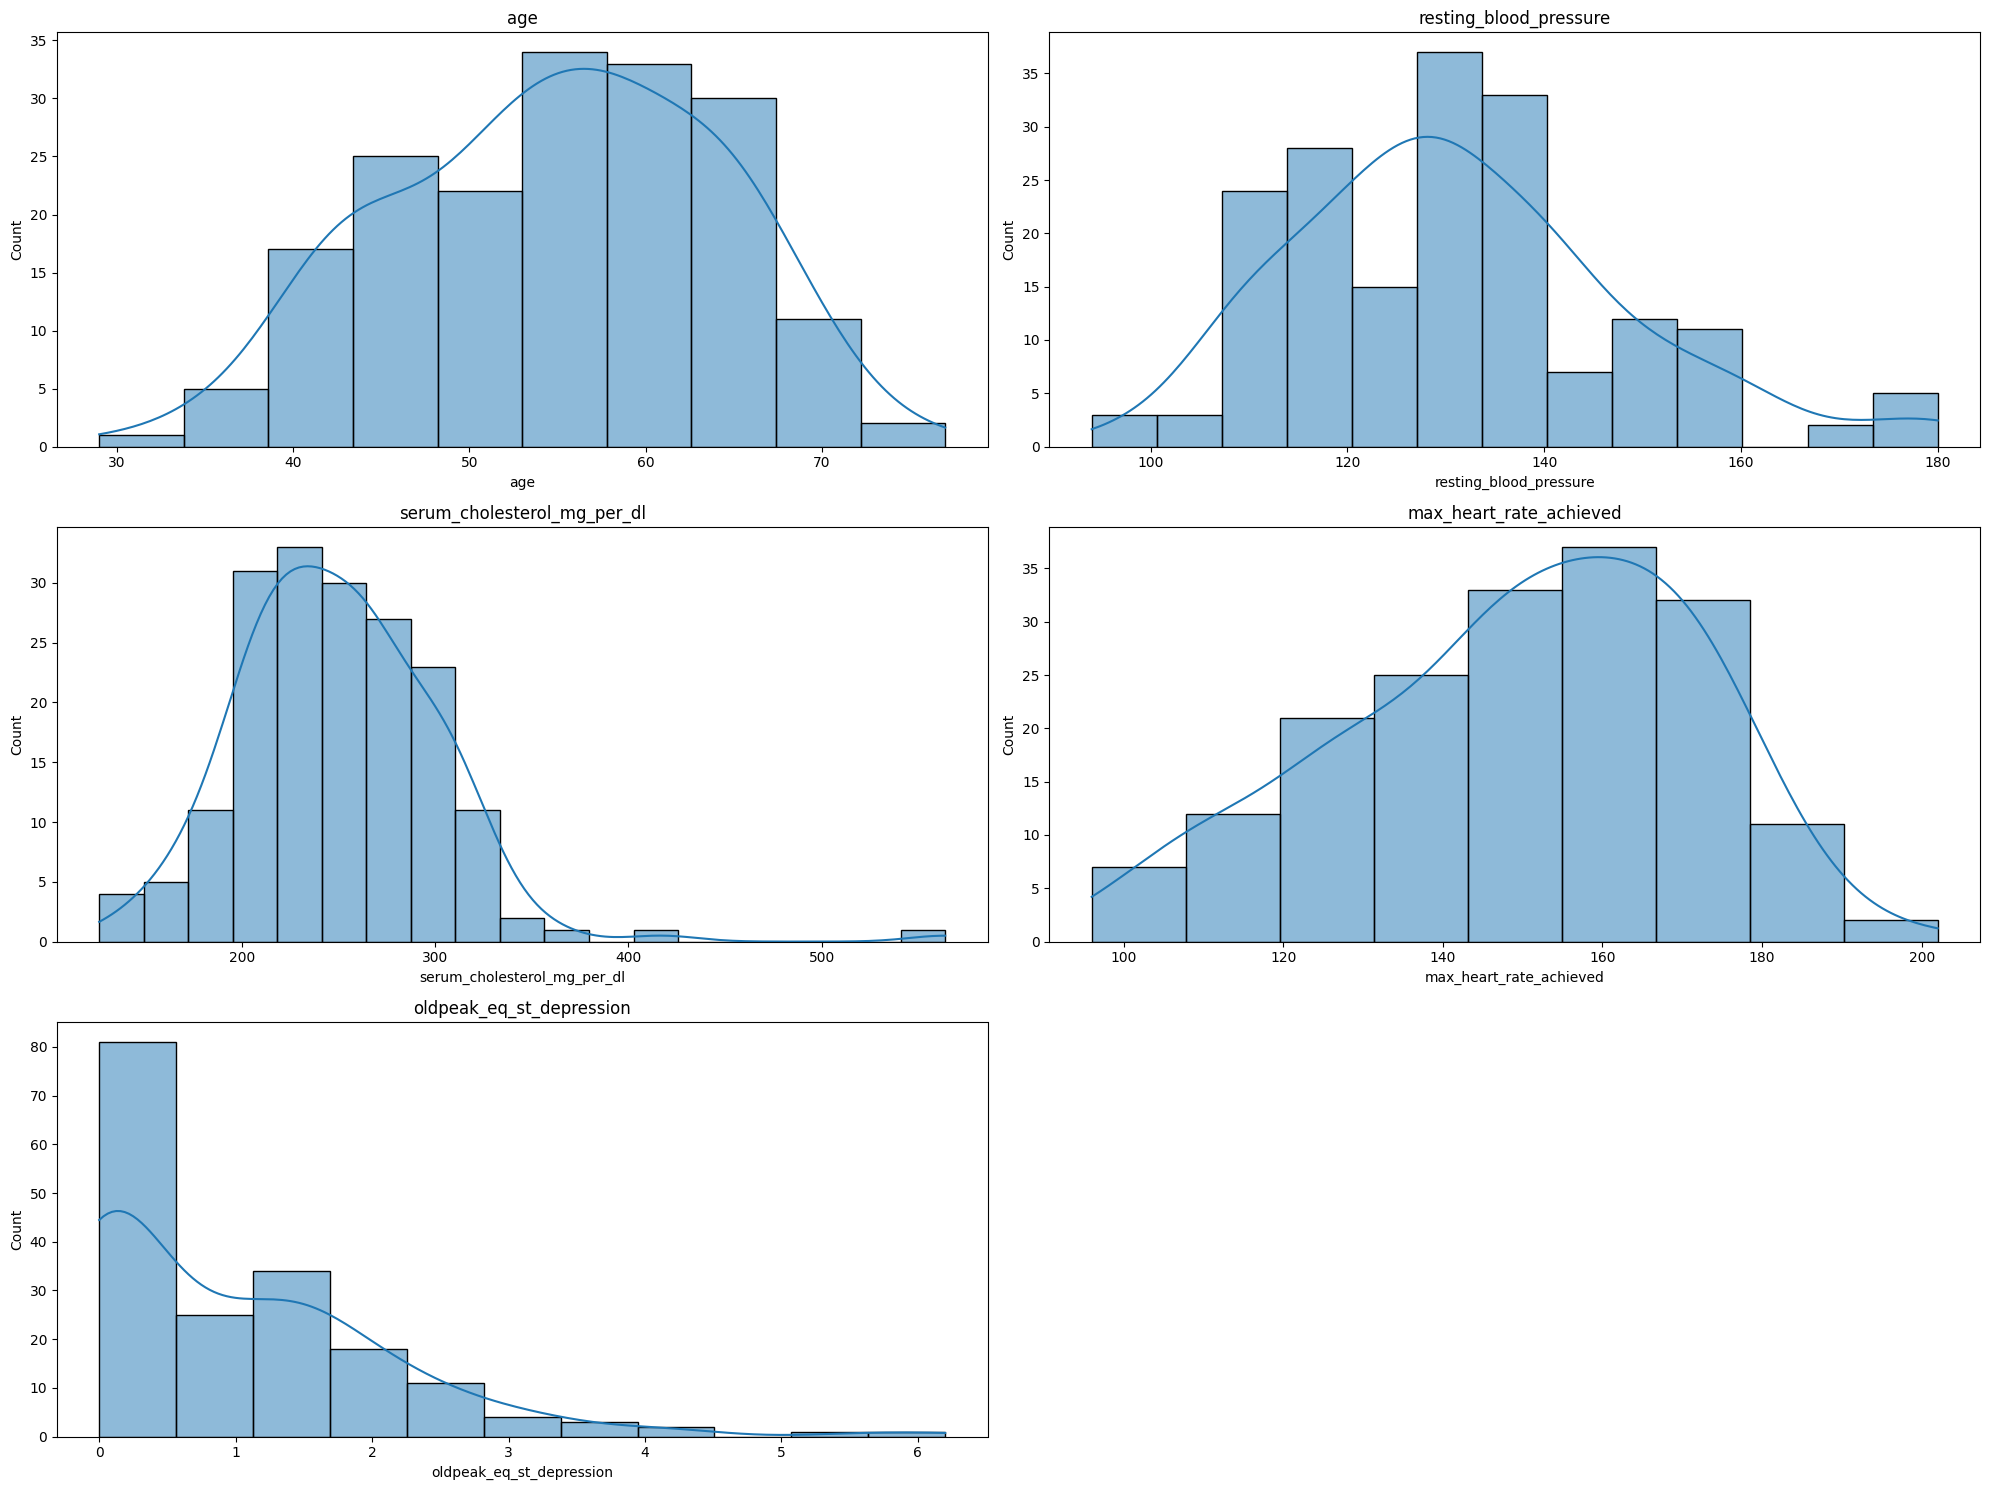

In [14]:
# for numerical columns
num_cols = [
    'age',
    'resting_blood_pressure',
    'serum_cholesterol_mg_per_dl',
    'max_heart_rate_achieved',
    'oldpeak_eq_st_depression'
]

plt.figure(figsize=(20,15))
plt_no=1

for cols in num_cols:
    plt.subplot(3,2,plt_no)
    sns.histplot(df[cols], kde=True)
    plt_no+=1
    plt.title(cols)

plt.tight_layout()
plt.show()

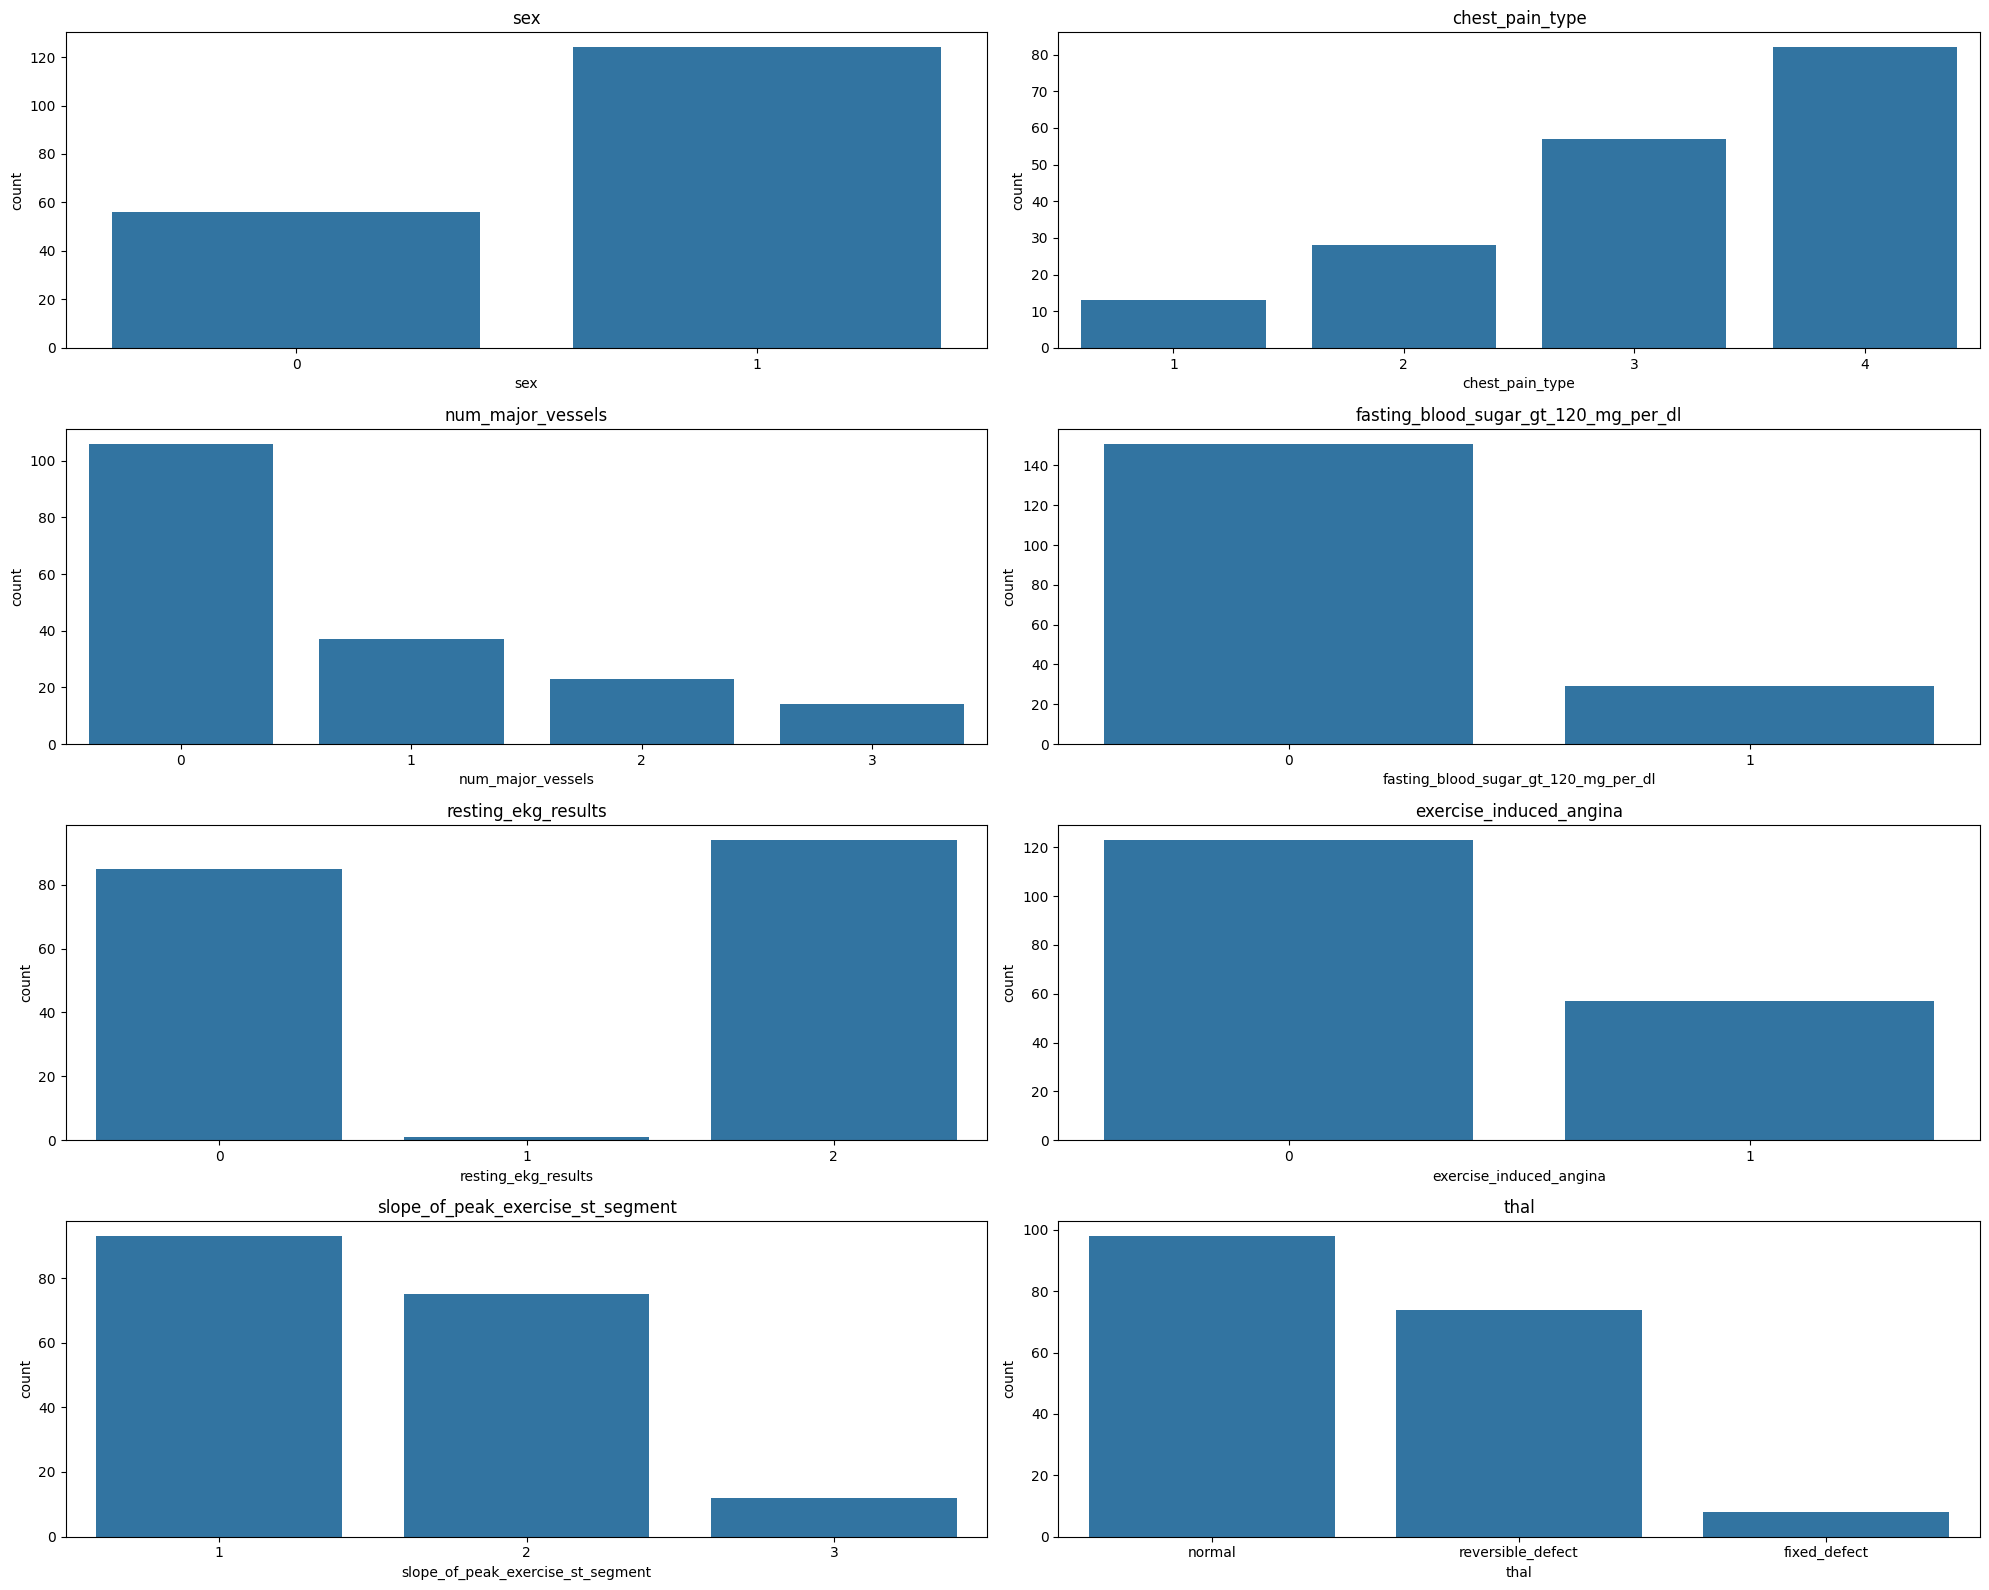

In [15]:
# for categorical cols
cat_cols = [
    'sex',
    'chest_pain_type',
    'num_major_vessels',
    'fasting_blood_sugar_gt_120_mg_per_dl',
    'resting_ekg_results',
    'exercise_induced_angina',
    'slope_of_peak_exercise_st_segment',
    'thal'
]

plt.figure(figsize=(20,16))
pt_no=1

for i in cat_cols:
    plt.subplot(4,2,pt_no)
    sns.countplot(x=i, data=df)
    pt_no+=1
    plt.title(i)

plt.tight_layout()
plt.show()

#### Bivariate analysis

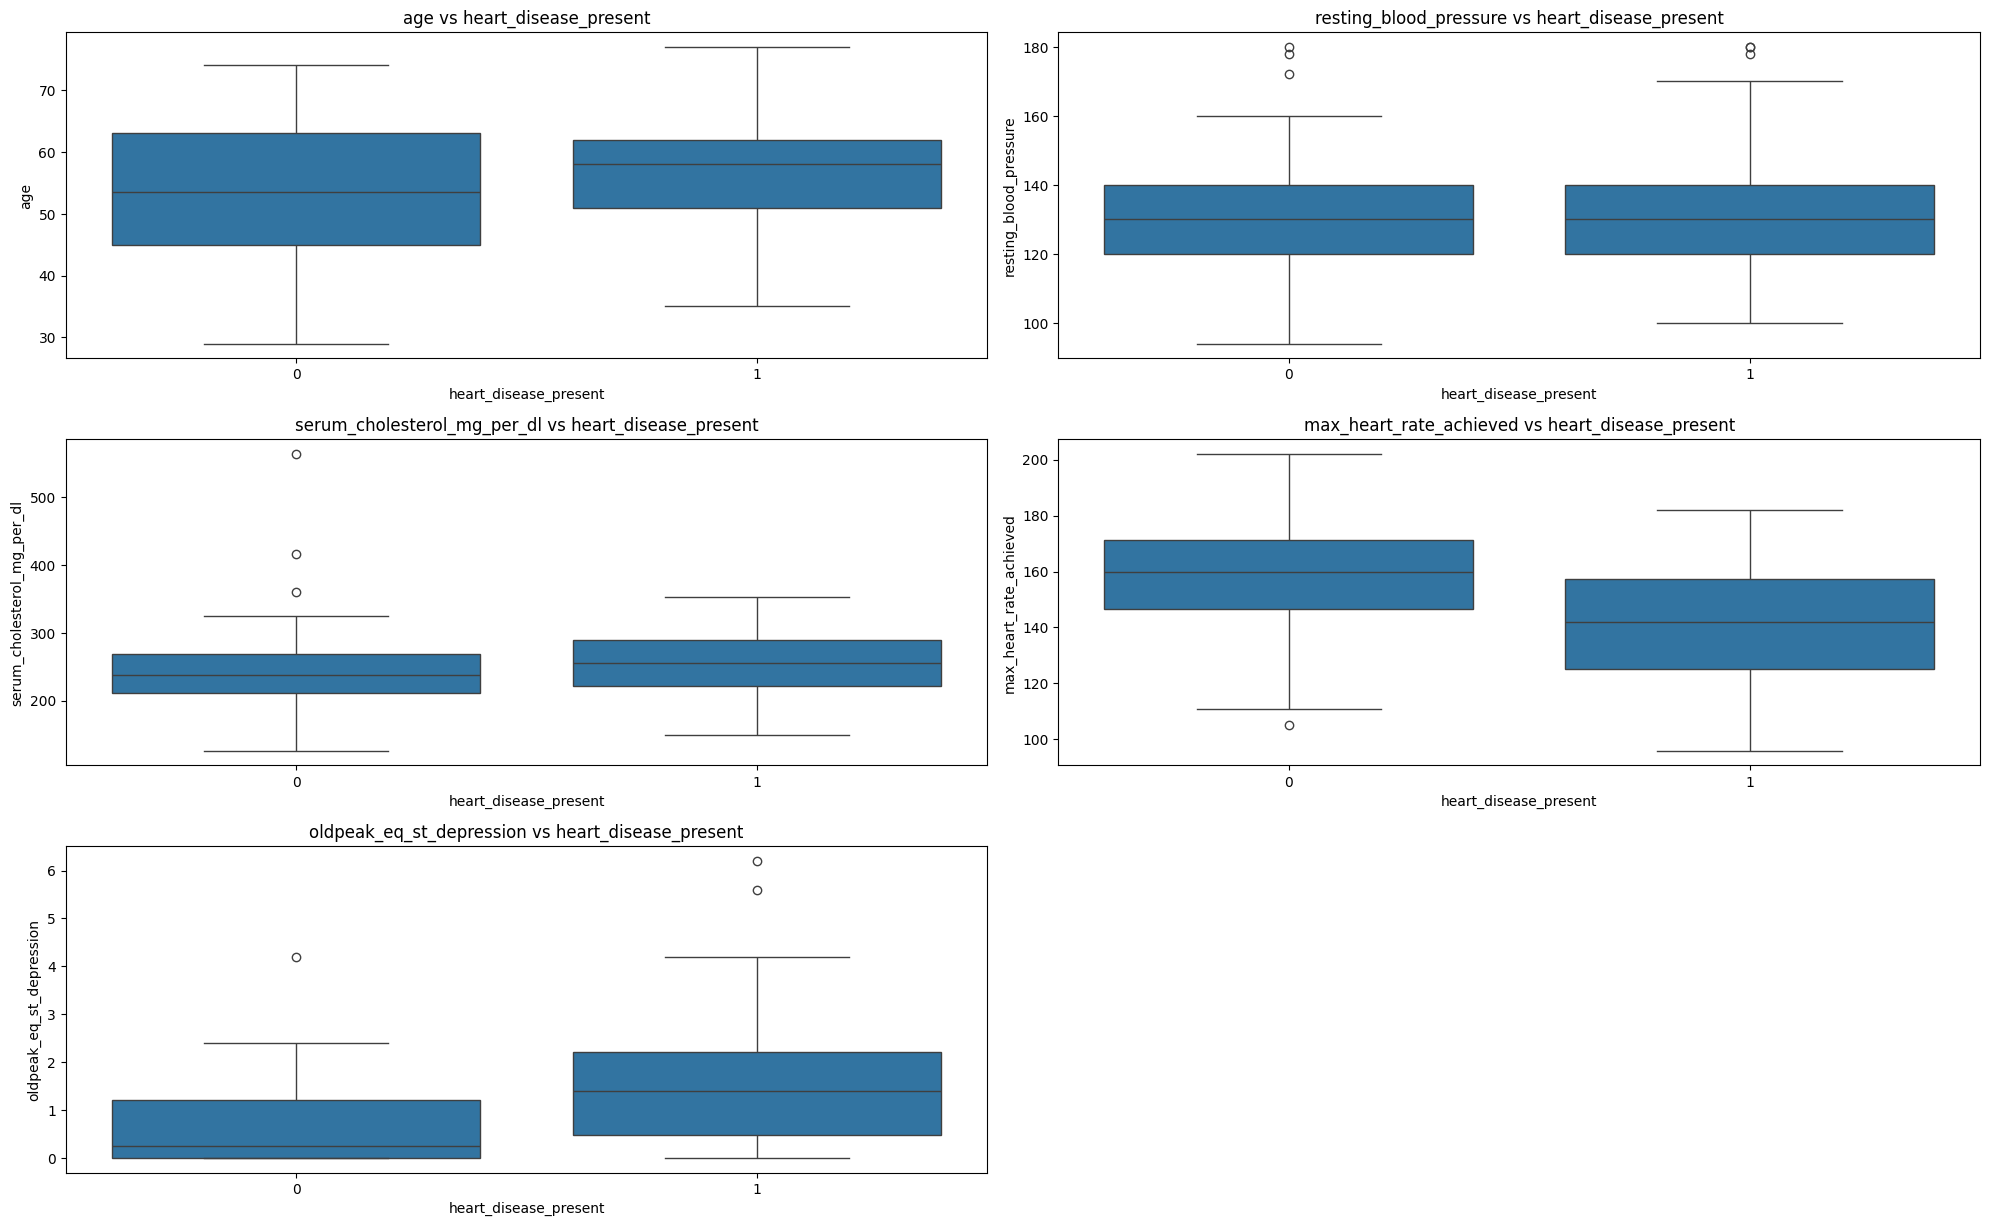

In [16]:
target = 'heart_disease_present'  
plt.figure(figsize=(20,16))
p_no =1
for col in num_cols:
    if col != target:
        plt.subplot(4,2,p_no)
        sns.boxplot(x=df[target], y=df[col])
        plt.title(f"{col} vs {target}")
        p_no+=1
plt.tight_layout()
plt.show()

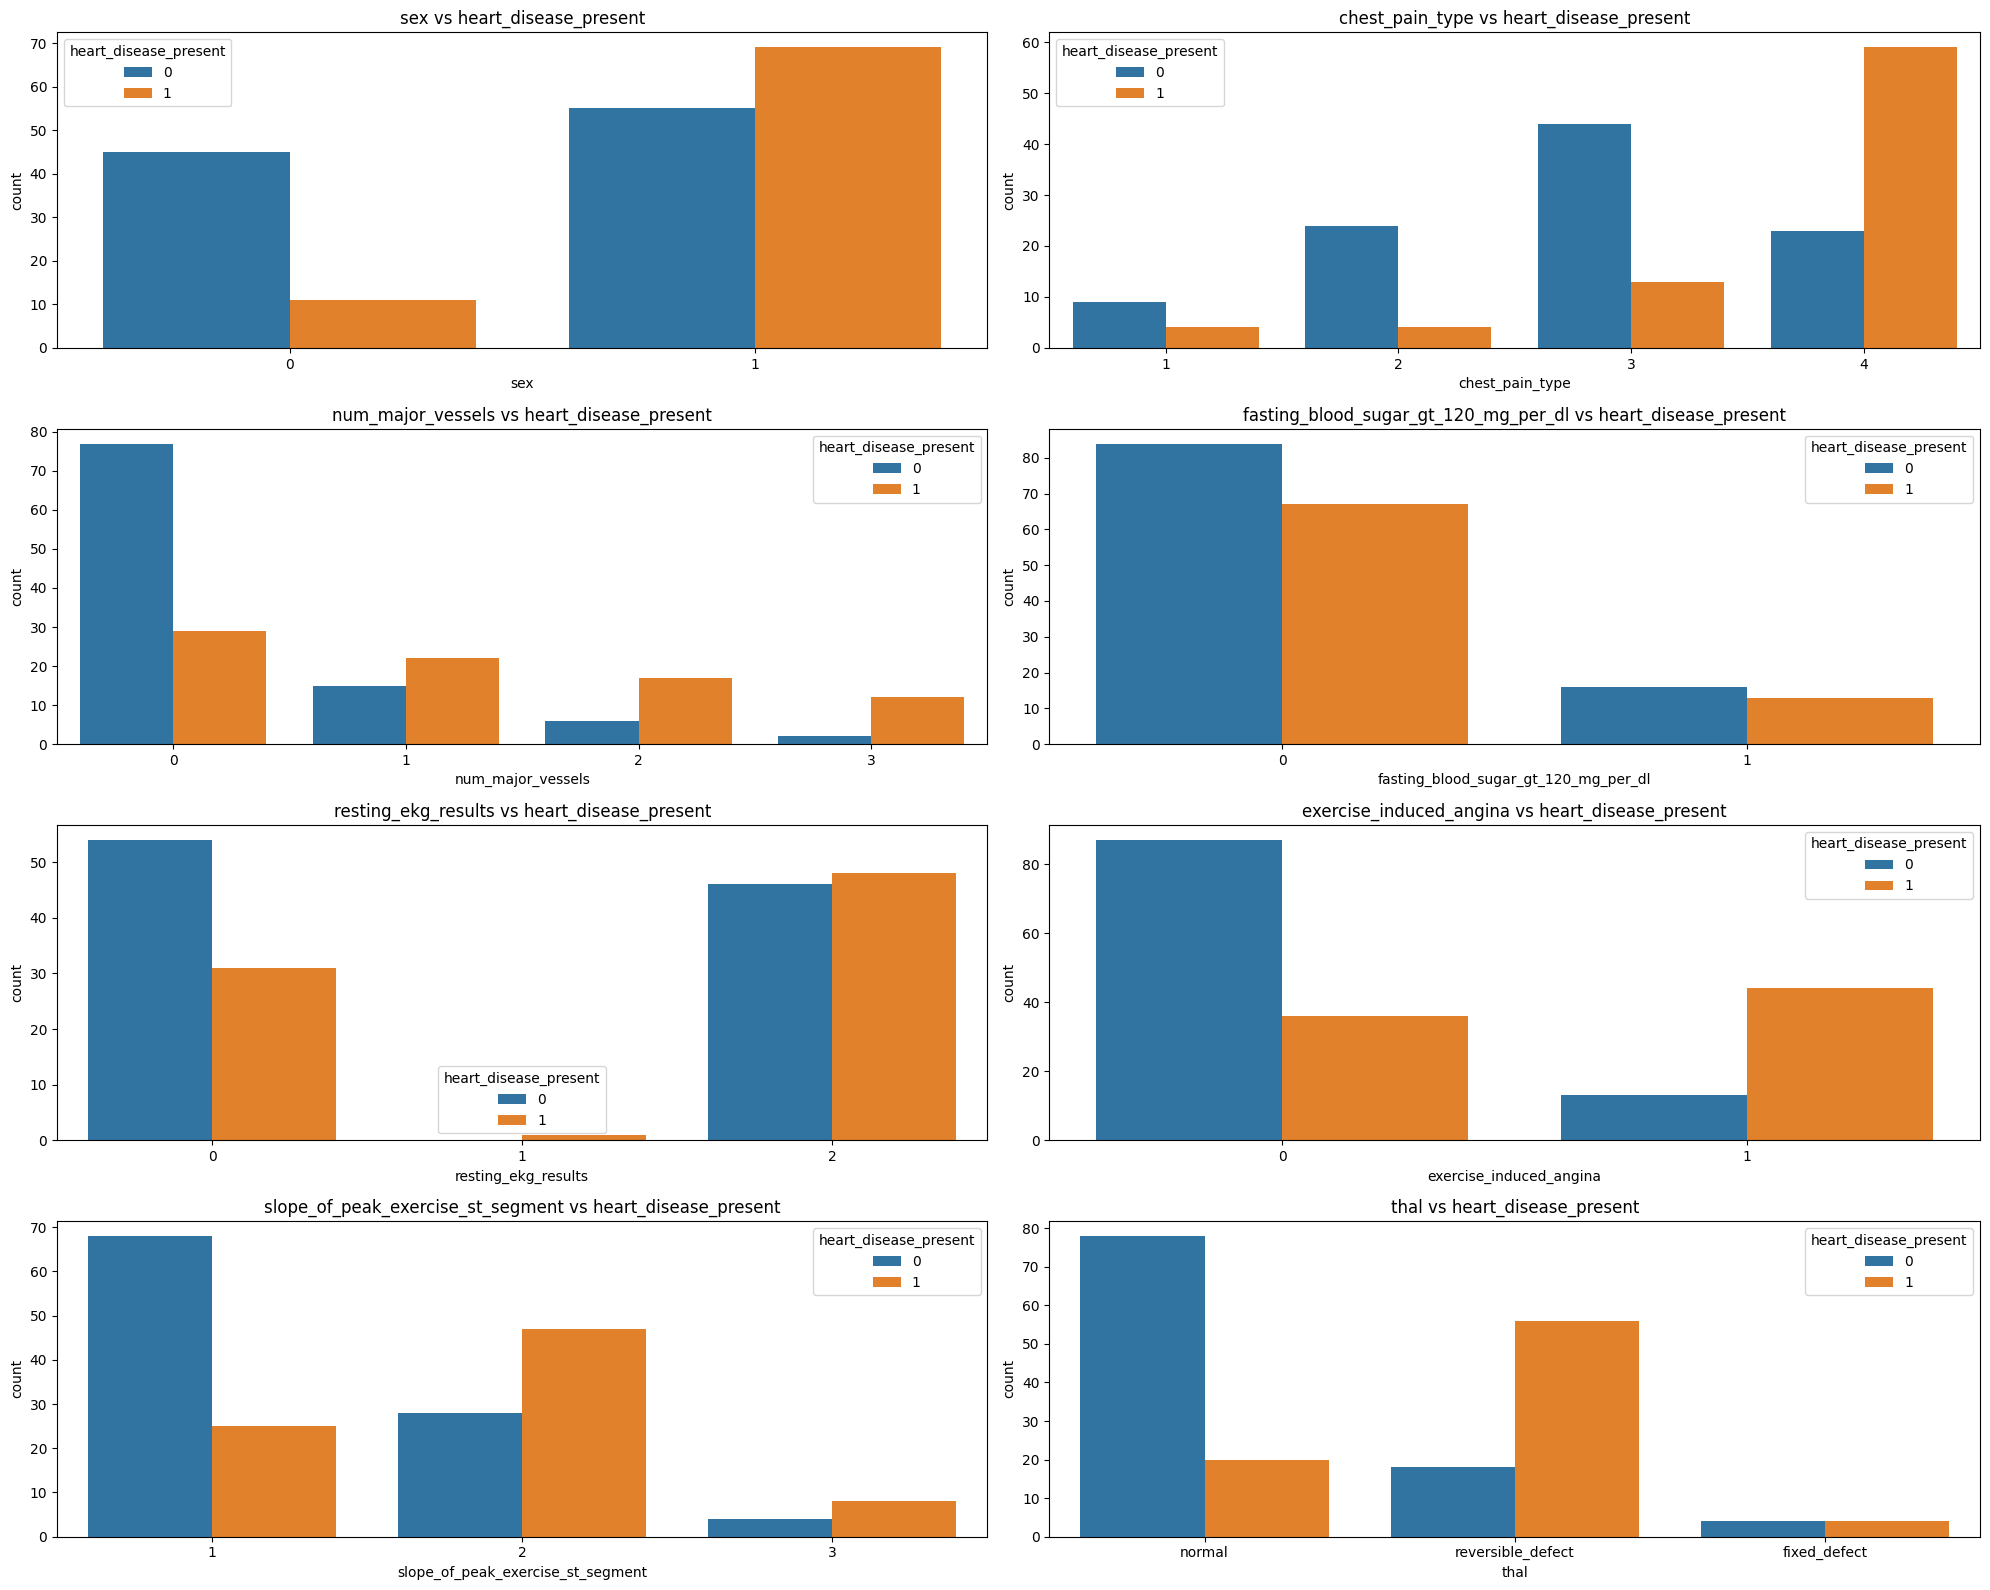

In [17]:
#for categorical cols
target = 'heart_disease_present'  
plt.figure(figsize=(20,16))
p_no =1
for cols in cat_cols:
        plt.subplot(4,2,p_no)
        sns.countplot(x=cols, hue=target, data=df)
        plt.title(f"{cols} vs {target}")
        p_no+=1
plt.tight_layout()
plt.show()

#### Multivariate analysis

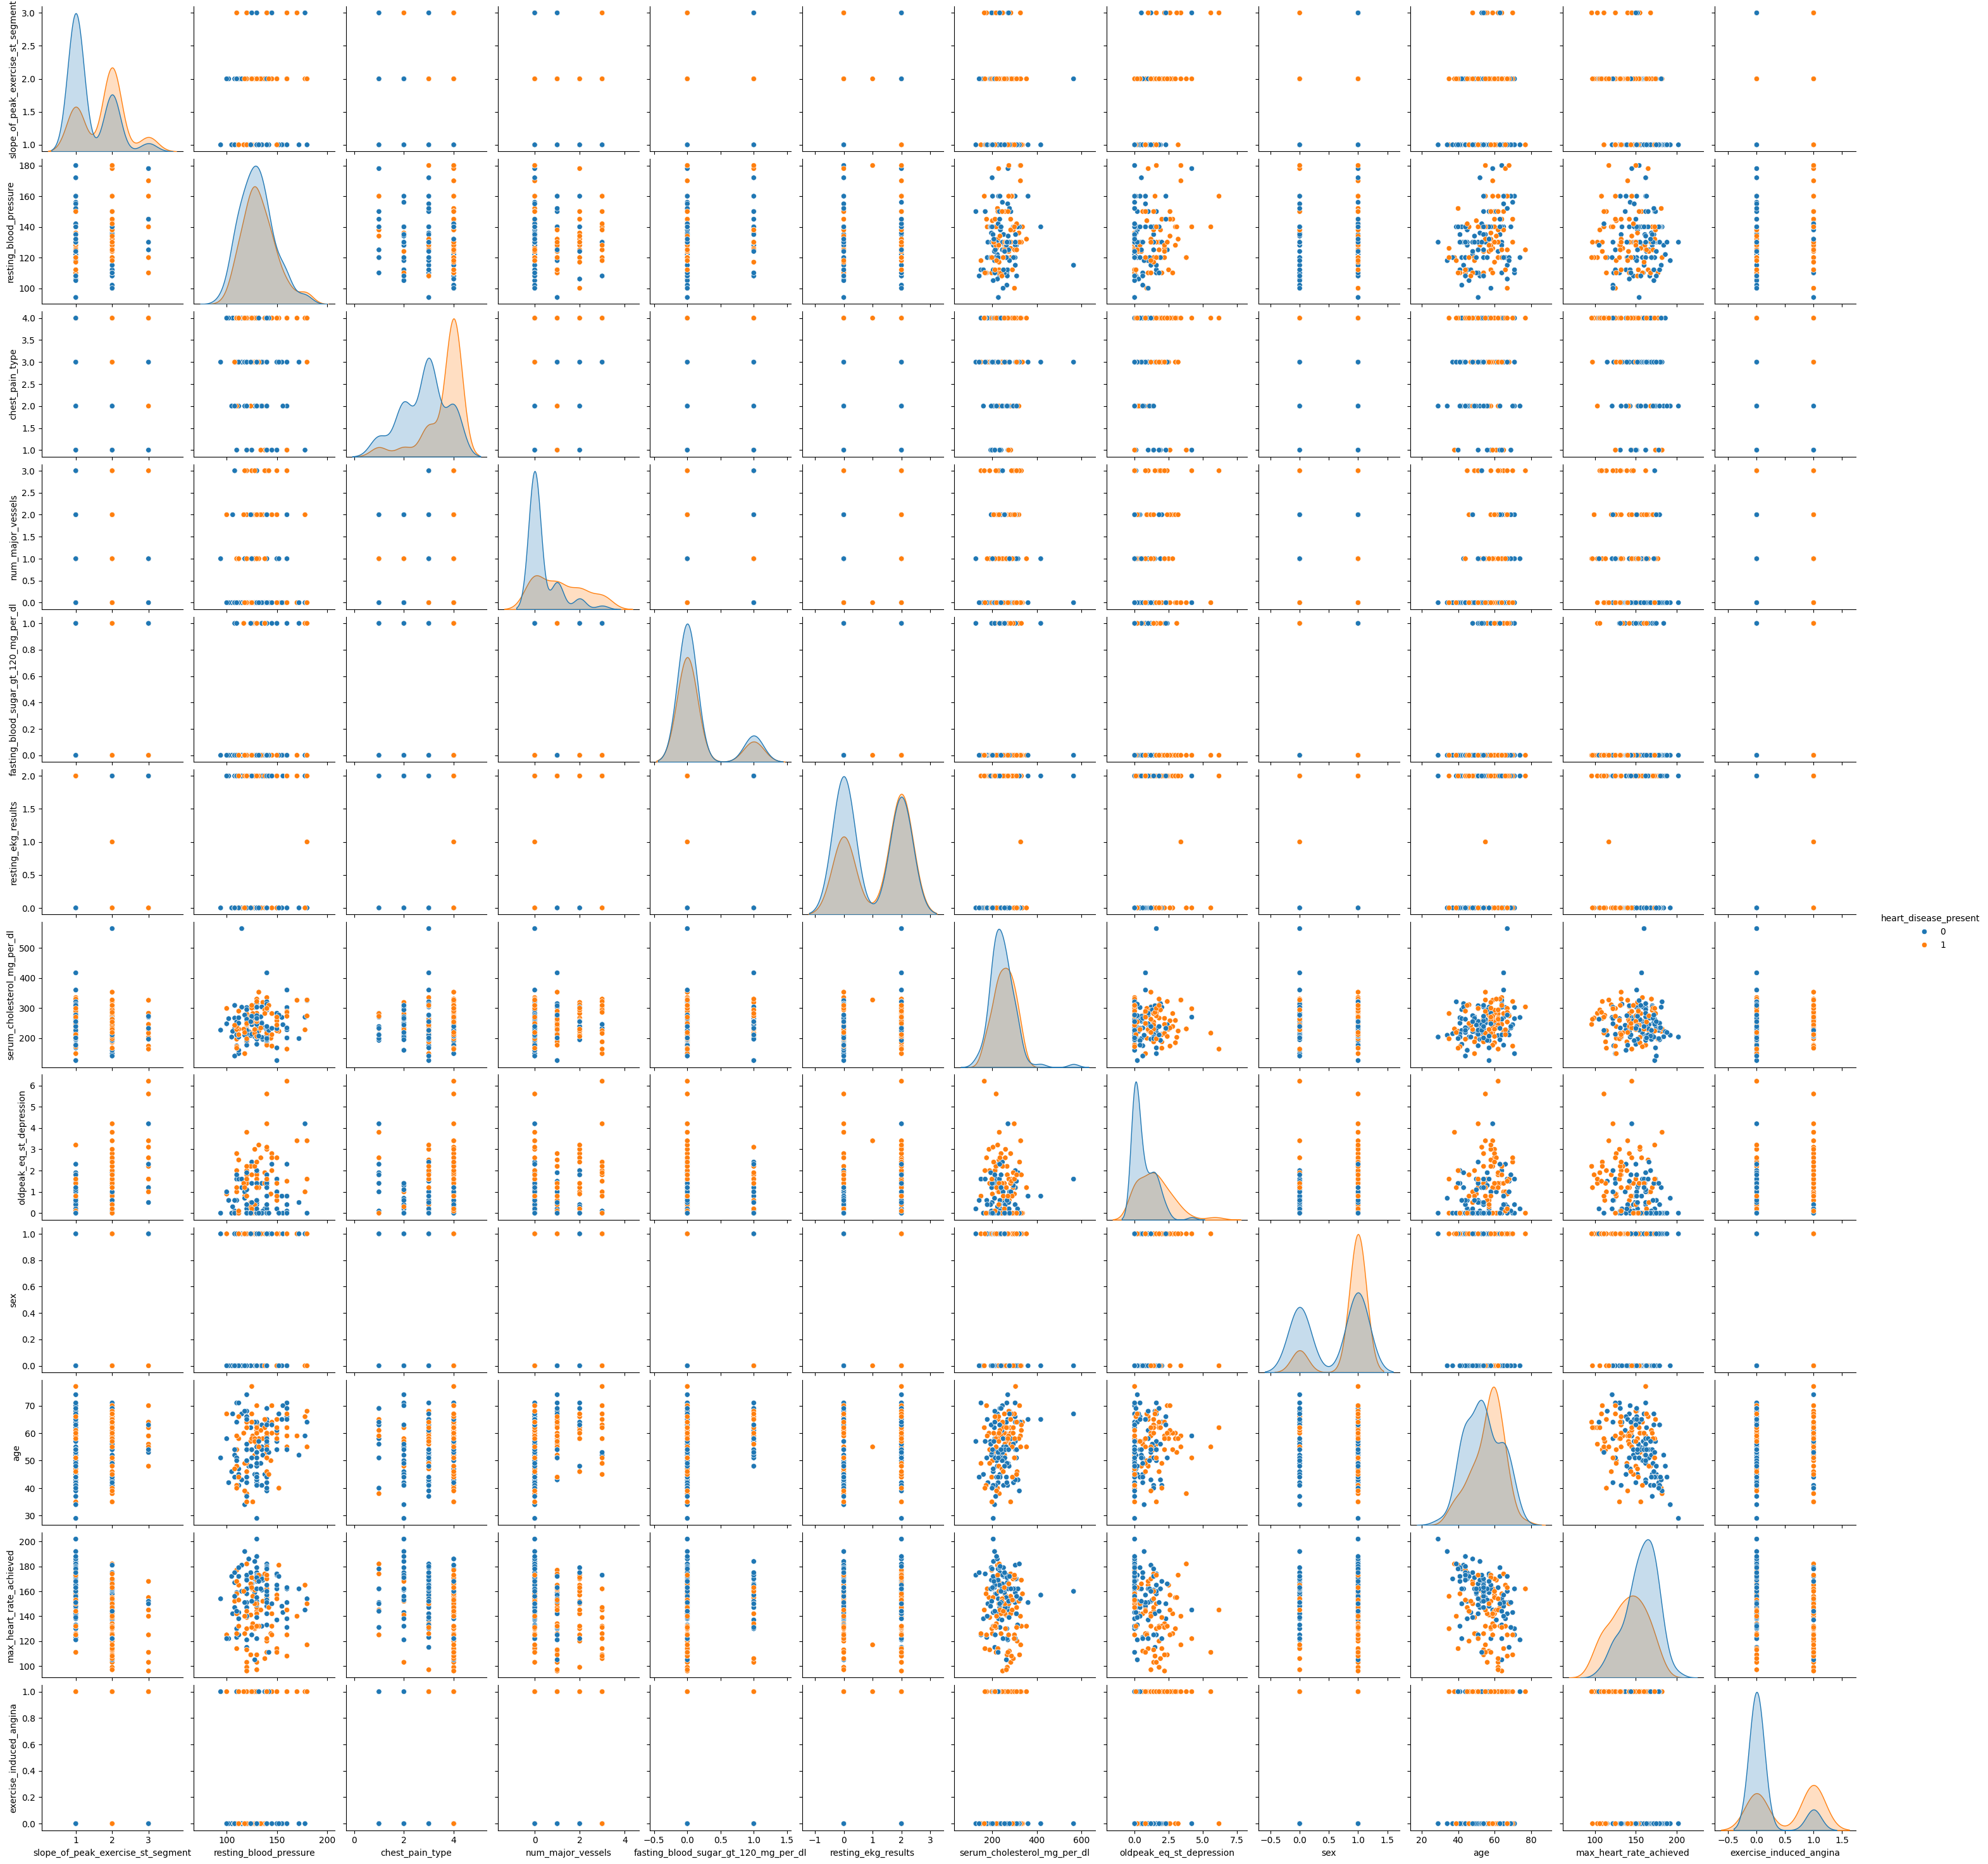

In [18]:
sns.pairplot(df, hue=target)
plt.show()

### Data Preprocessing and Feature Engineering

In [19]:
df.isnull().sum()

slope_of_peak_exercise_st_segment       0
thal                                    0
resting_blood_pressure                  0
chest_pain_type                         0
num_major_vessels                       0
fasting_blood_sugar_gt_120_mg_per_dl    0
resting_ekg_results                     0
serum_cholesterol_mg_per_dl             0
oldpeak_eq_st_depression                0
sex                                     0
age                                     0
max_heart_rate_achieved                 0
exercise_induced_angina                 0
heart_disease_present                   0
dtype: int64

In [20]:
df.duplicated().sum()

np.int64(0)

### Outlier detection

In [21]:
outliers = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_values = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    
    outliers[col] = len(outlier_values)

print("Outlier count in each column:")
print(outliers)

Outlier count in each column:
{'age': 0, 'resting_blood_pressure': 6, 'serum_cholesterol_mg_per_dl': 2, 'max_heart_rate_achieved': 0, 'oldpeak_eq_st_depression': 4}


In [22]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

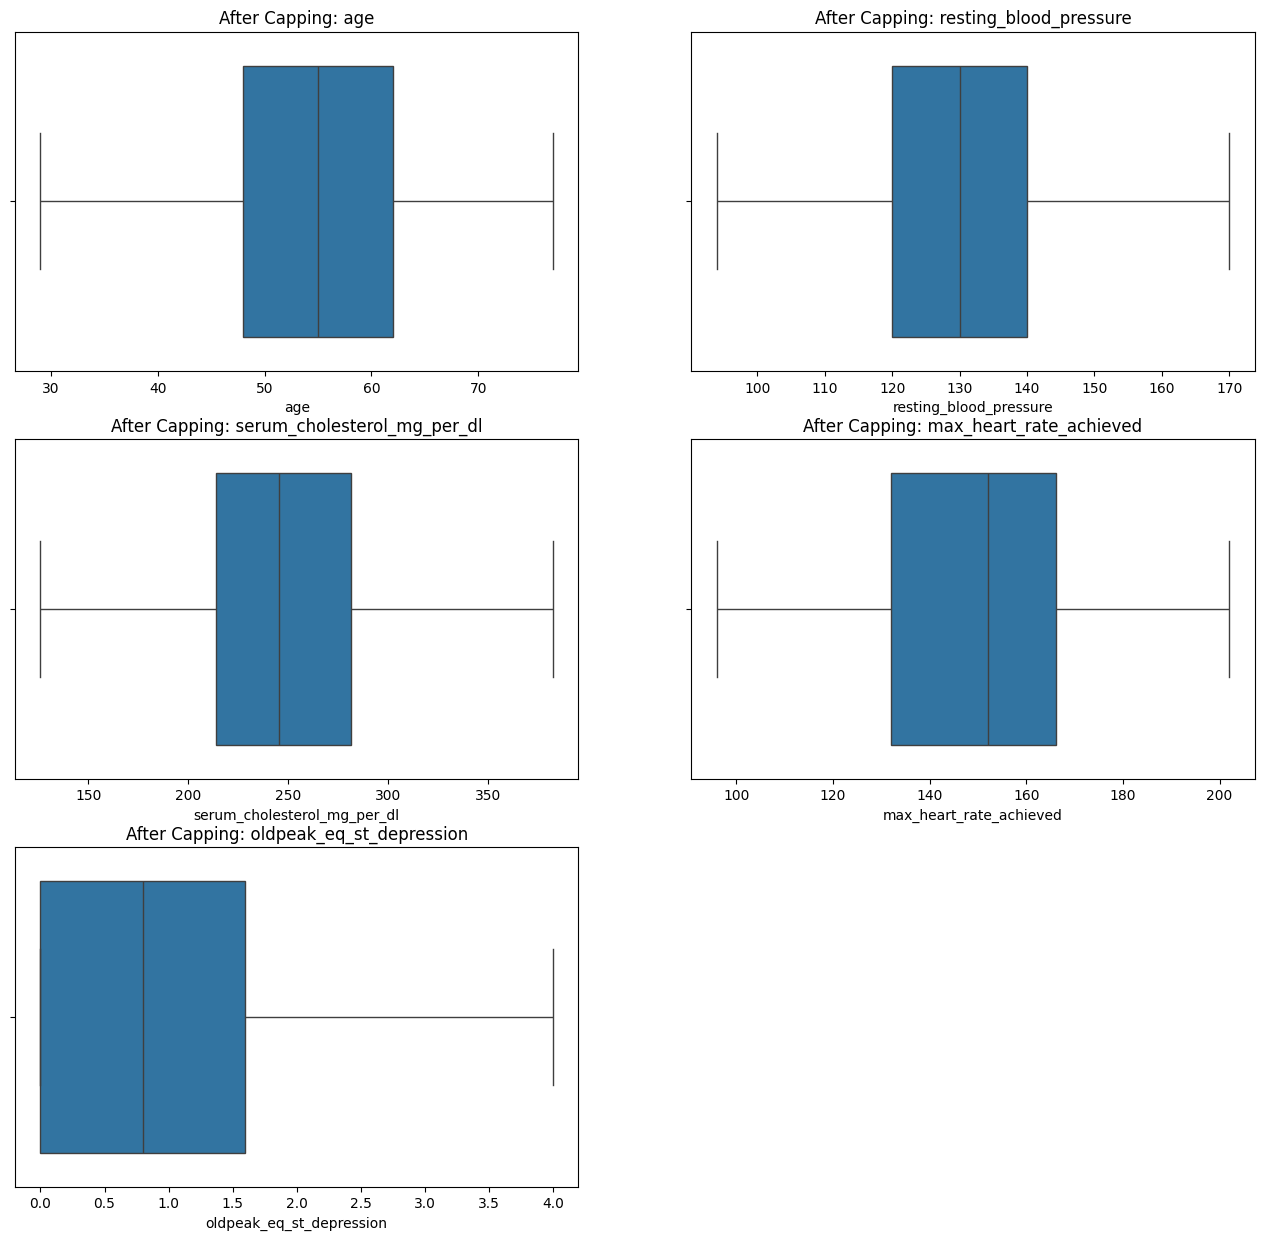

In [23]:
plt.figure(figsize=(16,15))
p_no=1

for col in num_cols:
    plt.subplot(3,2,p_no)
    sns.boxplot(x=df[col])
    plt.title(f"After Capping: {col}")
    p_no+=1

plt.show()

### Encoding

In [24]:
df= pd.get_dummies(df, drop_first=True)

In [25]:
df

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present,thal_normal,thal_reversible_defect
0,1,128.0,2,0,0,2,308.0,0.0,1,45.0,170.0,0,0,True,False
1,2,110.0,3,0,0,0,214.0,1.6,0,54.0,158.0,0,0,True,False
2,1,125.0,4,3,0,2,304.0,0.0,1,77.0,162.0,1,1,True,False
3,1,152.0,4,0,0,0,223.0,0.0,1,40.0,181.0,0,1,False,True
4,3,170.0,1,0,0,2,270.0,4.0,1,59.0,145.0,0,0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,2,125.0,4,2,1,0,254.0,0.2,1,67.0,163.0,0,1,False,True
176,2,170.0,4,0,0,1,327.0,3.4,0,55.0,117.0,1,1,True,False
177,2,125.0,3,0,0,0,309.0,1.8,1,64.0,131.0,1,1,False,True
178,1,124.0,3,2,1,0,255.0,0.0,1,48.0,175.0,0,0,True,False


### Multicollinearity

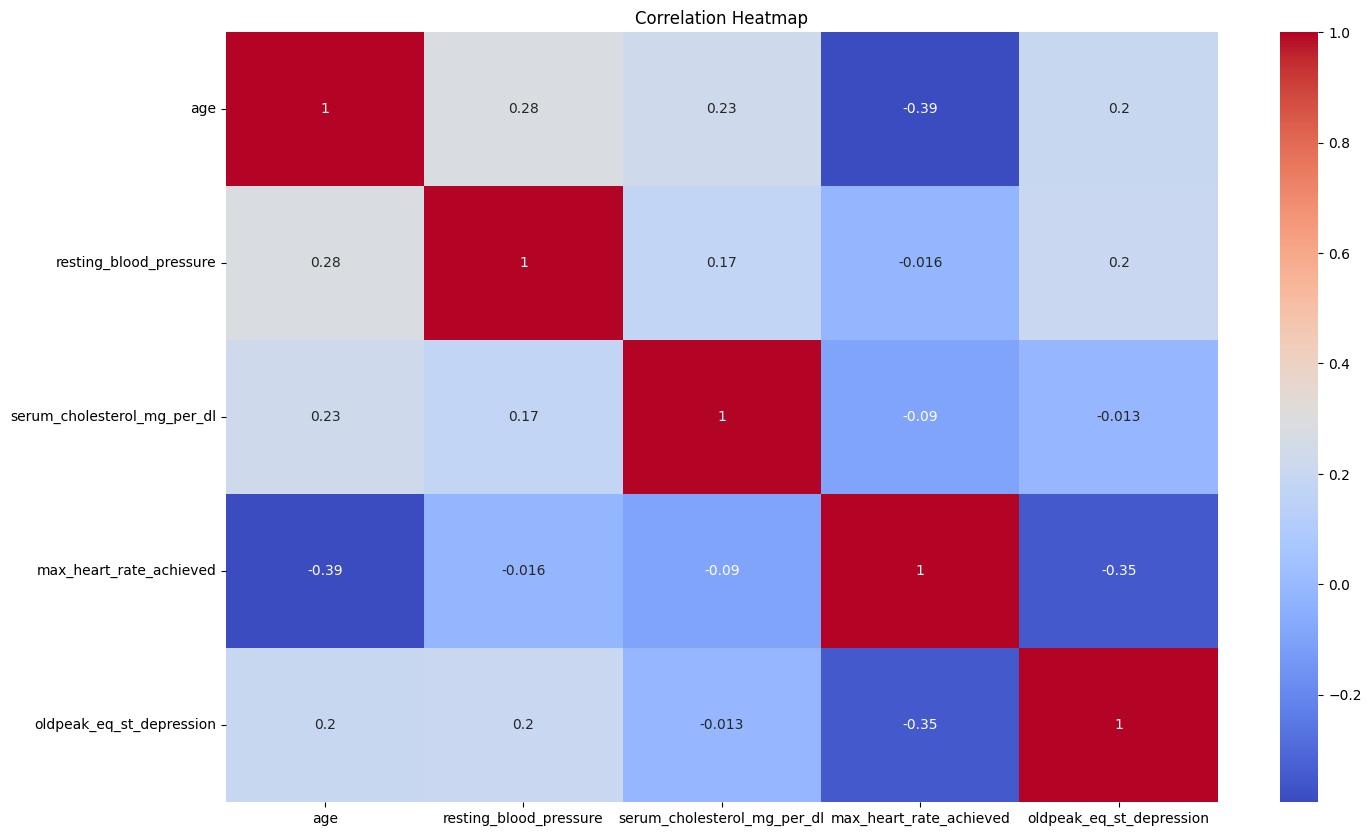

In [26]:
plt.figure(figsize=(16,10))

corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [27]:
corr>0.8

,age,resting_blood_pressure,serum_cholesterol_mg_per_dl,max_heart_rate_achieved,oldpeak_eq_st_depression
age,True,False,False,False,False
resting_blood_pressure,False,True,False,False,False
serum_cholesterol_mg_per_dl,False,False,True,False,False
max_heart_rate_achieved,False,False,False,True,False
oldpeak_eq_st_depression,False,False,False,False,True


### Scaling

In [28]:
X=df.drop('heart_disease_present', axis=1)

In [29]:
X

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,thal_normal,thal_reversible_defect
0,1,128.0,2,0,0,2,308.0,0.0,1,45.0,170.0,0,True,False
1,2,110.0,3,0,0,0,214.0,1.6,0,54.0,158.0,0,True,False
2,1,125.0,4,3,0,2,304.0,0.0,1,77.0,162.0,1,True,False
3,1,152.0,4,0,0,0,223.0,0.0,1,40.0,181.0,0,False,True
4,3,170.0,1,0,0,2,270.0,4.0,1,59.0,145.0,0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,2,125.0,4,2,1,0,254.0,0.2,1,67.0,163.0,0,False,True
176,2,170.0,4,0,0,1,327.0,3.4,0,55.0,117.0,1,True,False
177,2,125.0,3,0,0,0,309.0,1.8,1,64.0,131.0,1,False,True
178,1,124.0,3,2,1,0,255.0,0.0,1,48.0,175.0,0,True,False


In [30]:
y=df['heart_disease_present']

In [31]:
y

0      0
1      0
2      1
3      1
4      0
      ..
175    1
176    1
177    1
178    0
179    0
Name: heart_disease_present, Length: 180, dtype: int64

In [32]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X[num_cols]=sc.fit_transform(X[num_cols])

In [33]:
X

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,thal_normal,thal_reversible_defect
0,1,-0.187145,2,0,0,2,1.263895,-0.954372,1,-1.053964,0.932485,0,True,False
1,2,-1.293623,3,0,0,0,-0.716574,0.593258,0,-0.087134,0.387084,0,True,False
2,1,-0.371558,4,3,0,2,1.179619,-0.954372,1,2.383654,0.568884,1,True,False
3,1,1.288159,4,0,0,0,-0.526954,-0.954372,1,-1.591092,1.432436,0,False,True
4,3,2.394637,1,0,0,2,0.463280,2.914704,1,0.449994,-0.203768,0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,2,-0.371558,4,2,1,0,0.126179,-0.760918,1,1.309398,0.614334,0,False,True
176,2,2.394637,4,0,0,1,1.664202,2.334342,0,0.020291,-1.476372,1,True,False
177,2,-0.371558,3,0,0,0,1.284963,0.786712,1,0.987122,-0.840070,1,False,True
178,1,-0.433029,3,2,1,0,0.147248,-0.954372,1,-0.731688,1.159736,0,True,False


### Model Creation

In [34]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)

In [35]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(144, 14)
(36, 14)
(144,)
(36,)


In [36]:
df['heart_disease_present'].value_counts()

heart_disease_present
0    100
1     80
Name: count, dtype: int64

### Logistic Regression

In [37]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)

In [38]:
y_pred

array([0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0])

In [39]:
pd.DataFrame({'Actual':y_test,'Predicted':y_pred,'Error':y_test-y_pred})

,Actual,Predicted,Error
19,1,0,1
42,0,0,0
153,1,0,1
78,1,1,0
145,0,0,0
15,1,1,0
24,0,0,0
68,0,0,0
113,1,1,0
118,1,1,0


#### Evaluation

In [40]:
from sklearn.metrics import *

In [41]:
accuracy_score(y_test,y_pred)

0.8611111111111112

In [42]:
print(confusion_matrix(y_test, y_pred))

[[16  0]
 [ 5 15]]


<Axes: >

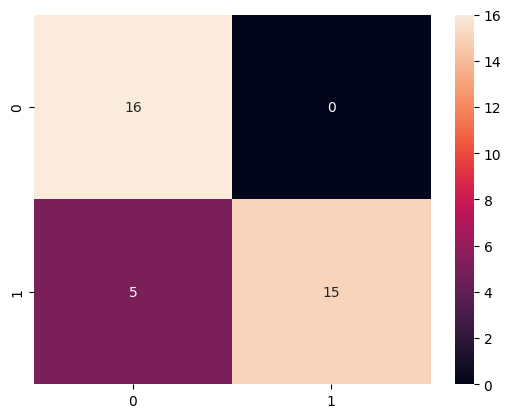

In [43]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True)

In [44]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      1.00      0.86        16
           1       1.00      0.75      0.86        20

    accuracy                           0.86        36
   macro avg       0.88      0.88      0.86        36
weighted avg       0.89      0.86      0.86        36



### Random Forest Classifier

In [45]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred_rf=rf.predict(X_test)

In [46]:
y_pred_rf

array([0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0])

In [47]:
pd.DataFrame({'Actual':y_test,'Predicted':y_pred_rf,'Error':y_test-y_pred_rf})

,Actual,Predicted,Error
19,1,0,1
42,0,0,0
153,1,0,1
78,1,1,0
145,0,0,0
15,1,1,0
24,0,0,0
68,0,0,0
113,1,1,0
118,1,1,0


#### Evaluation

In [48]:
accuracy_score(y_test,y_pred_rf)

0.8611111111111112

In [49]:
print(confusion_matrix(y_test, y_pred_rf))

[[16  0]
 [ 5 15]]


<Axes: >

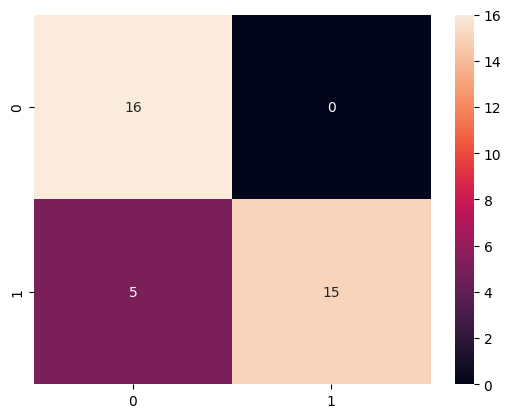

In [50]:
sns.heatmap(confusion_matrix(y_test,y_pred_rf),annot=True)

In [51]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.76      1.00      0.86        16
           1       1.00      0.75      0.86        20

    accuracy                           0.86        36
   macro avg       0.88      0.88      0.86        36
weighted avg       0.89      0.86      0.86        36



In [52]:
#hyperparameter tuning
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import RandomizedSearchCV
params={
    'n_estimators':[100,200],'max_depth':[3,4,5,None],'max_features':['sqrt','log2'],'min_samples_leaf':[1,2,4],
    'min_samples_split':[2,5,10],'criterion':['gini','entropy']}
rfc=RandomForestClassifier(random_state=42)
rf_1=RandomizedSearchCV(estimator=rfc, scoring='accuracy', param_distributions= params ,n_iter=20, cv=5, verbose=2, n_jobs=-1)
rf_1.fit(X_train,y_train)
rf_best_params=rf_1.best_params_
print(f"Best parameters: {rf_best_params}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None, 'criterion': 'gini'}


In [53]:
rf_2=RandomForestClassifier(**rf_best_params)
rf_2.fit(X_train,y_train)
y_pred_rf_2=rf_2.predict(X_test)

In [54]:
y_pred_rf_2

array([0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0])

In [55]:
accuracy_score(y_test,y_pred_rf_2)

0.8333333333333334

[[15  1]
 [ 5 15]]


<Axes: >

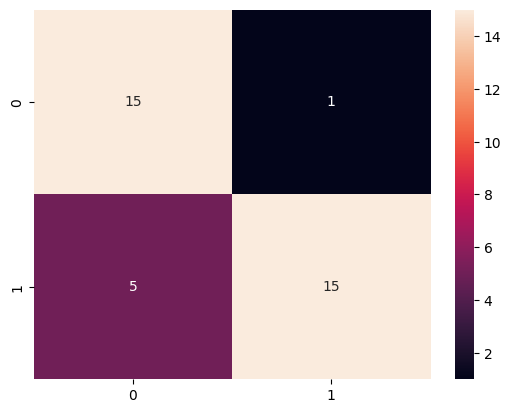

In [56]:
print(confusion_matrix(y_test, y_pred_rf_2))
sns.heatmap(confusion_matrix(y_test,y_pred_rf_2),annot=True)

In [57]:
print(classification_report(y_test, y_pred_rf_2))

              precision    recall  f1-score   support

           0       0.75      0.94      0.83        16
           1       0.94      0.75      0.83        20

    accuracy                           0.83        36
   macro avg       0.84      0.84      0.83        36
weighted avg       0.85      0.83      0.83        36



In [58]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf_2, X, y, cv=5,scoring='accuracy')
print("CV Accuracy:", cv_scores.mean())

CV Accuracy: 0.8055555555555556


### Decision Tree Classifier

In [59]:
from sklearn.tree import DecisionTreeClassifier
dtc=DecisionTreeClassifier()
dtc.fit(X_train,y_train)
y_pred_dtc=dtc.predict(X_test)

In [60]:
y_pred_dtc

array([0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0])

In [61]:
pd.DataFrame({'Actual':y_test,'Predicted':y_pred_dtc,'Error':y_test-y_pred_dtc})

,Actual,Predicted,Error
19,1,0,1
42,0,0,0
153,1,0,1
78,1,1,0
145,0,0,0
15,1,1,0
24,0,0,0
68,0,0,0
113,1,0,1
118,1,1,0


#### Evaluation

In [62]:
accuracy_score(y_test,y_pred_dtc)

0.7777777777777778

[[16  0]
 [ 8 12]]


<Axes: >

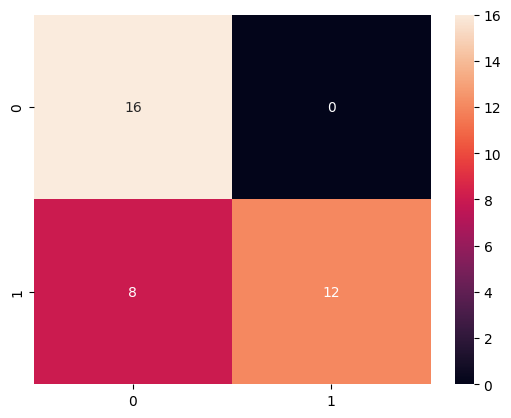

In [63]:
print(confusion_matrix(y_test, y_pred_dtc))
sns.heatmap(confusion_matrix(y_test,y_pred_dtc),annot=True)

In [64]:
print(classification_report(y_test, y_pred_dtc))

              precision    recall  f1-score   support

           0       0.67      1.00      0.80        16
           1       1.00      0.60      0.75        20

    accuracy                           0.78        36
   macro avg       0.83      0.80      0.78        36
weighted avg       0.85      0.78      0.77        36



In [65]:
#hyperparameter tuning
params_dt={'criterion':['gini','entropy'], 'splitter':['best', 'random'], 'max_depth':[None,3,5,7,9],
        "min_samples_split": [2,3,4,5,6,7], "min_samples_leaf": list(range(1,10))}
dt_cf= DecisionTreeClassifier(random_state=42)
dt_cv=RandomizedSearchCV(estimator=dt_cf, param_distributions=params_dt, scoring = 'accuracy', n_jobs = -1, verbose = 2, cv = 5, n_iter=20,
                         random_state=42)
dt_cv.fit(X_train,y_train)
dt_best_params= dt_cv.best_params_
print(f'best parameters :{dt_best_params}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits
best parameters :{'splitter': 'best', 'min_samples_split': 4, 'min_samples_leaf': 7, 'max_depth': None, 'criterion': 'entropy'}


In [66]:
dt_2=DecisionTreeClassifier(**dt_best_params)
dt_2.fit(X_train,y_train)
y_pred_dt2=dt_2.predict(X_test)

In [67]:
y_pred_dt2

array([0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0])

In [68]:
accuracy_score(y_test,y_pred_dt2)

0.7777777777777778

[[14  2]
 [ 6 14]]


<Axes: >

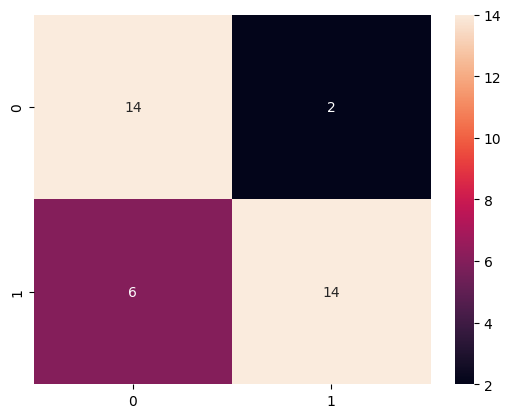

In [69]:
print(confusion_matrix(y_test, y_pred_dt2))
sns.heatmap(confusion_matrix(y_test,y_pred_dt2),annot=True)

In [70]:
print(classification_report(y_test, y_pred_dt2))

              precision    recall  f1-score   support

           0       0.70      0.88      0.78        16
           1       0.88      0.70      0.78        20

    accuracy                           0.78        36
   macro avg       0.79      0.79      0.78        36
weighted avg       0.80      0.78      0.78        36



In [71]:
cv_scores = cross_val_score(dt_2, X, y, cv=5,scoring='accuracy')
print("CV Accuracy:", cv_scores.mean())

CV Accuracy: 0.6777777777777778


### Gradient Boosting Classifier

In [72]:
from sklearn.ensemble import GradientBoostingClassifier
gbc=GradientBoostingClassifier()
gbc.fit(X_train,y_train)
y_pred_gbc=gbc.predict(X_test)

In [73]:
y_pred_gbc

array([0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0])

In [74]:
pd.DataFrame({'Actual':y_test,'Predicted':y_pred_gbc,'Error':y_test-y_pred_gbc})

,Actual,Predicted,Error
19,1,0,1
42,0,0,0
153,1,0,1
78,1,1,0
145,0,0,0
15,1,1,0
24,0,0,0
68,0,0,0
113,1,0,1
118,1,1,0


#### Evaluation

In [75]:
accuracy_score(y_test,y_pred_gbc)

0.75

[[13  3]
 [ 6 14]]


<Axes: >

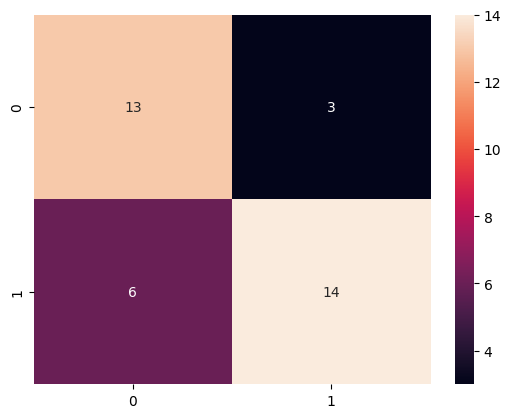

In [76]:
print(confusion_matrix(y_test, y_pred_gbc))
sns.heatmap(confusion_matrix(y_test,y_pred_gbc),annot=True)

In [77]:
print(classification_report(y_test, y_pred_gbc))

              precision    recall  f1-score   support

           0       0.68      0.81      0.74        16
           1       0.82      0.70      0.76        20

    accuracy                           0.75        36
   macro avg       0.75      0.76      0.75        36
weighted avg       0.76      0.75      0.75        36



In [78]:
#hyperparameter tuning

params_gbc={'learning_rate': [0.01, 0.03, 0.06, 0.1, 0.4, 0.5, 0.6, 0.7], 'max_depth': [5,6,7,8,9,10],
    'n_estimators': [50, 65, 80, 100],'subsample':[0.8,0.9,1.0],'min_samples_split':[2,5,10]}
gb= GradientBoostingClassifier(random_state=42)
gb_cv = RandomizedSearchCV(estimator = gb, scoring = 'accuracy', param_distributions = params_gbc, cv = 5, verbose = 2, n_jobs = -1, n_iter=20)
gb_cv.fit(X_train, y_train)
gb_best_params = gb_cv.best_params_
print(f"Best parameters: {gb_best_params}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'subsample': 0.9, 'n_estimators': 50, 'min_samples_split': 10, 'max_depth': 6, 'learning_rate': 0.03}


In [79]:
gbc_2=GradientBoostingClassifier(**gb_best_params)
gbc_2.fit(X_train,y_train)
y_pred_gbc2=gbc_2.predict(X_test)

In [80]:
y_pred_gbc2

array([0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0])

In [81]:
accuracy_score(y_test,y_pred_gbc2)

0.75

[[13  3]
 [ 6 14]]


<Axes: >

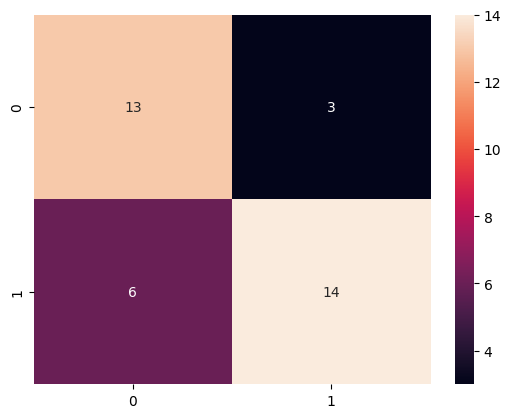

In [82]:
print(confusion_matrix(y_test, y_pred_gbc2))
sns.heatmap(confusion_matrix(y_test,y_pred_gbc2),annot=True)

In [83]:
print(classification_report(y_test, y_pred_gbc2))

              precision    recall  f1-score   support

           0       0.68      0.81      0.74        16
           1       0.82      0.70      0.76        20

    accuracy                           0.75        36
   macro avg       0.75      0.76      0.75        36
weighted avg       0.76      0.75      0.75        36



In [84]:
cv_scores = cross_val_score(gbc_2, X, y, cv=5,scoring='accuracy')
print("CV Accuracy:", cv_scores.mean())

CV Accuracy: 0.8111111111111111


### XGBoost Classifier

In [85]:
from xgboost import XGBClassifier
xgb= XGBClassifier()
xgb.fit(X_train,y_train)
y_pred_xgb=xgb.predict(X_test)

In [86]:
y_pred_xgb

array([0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0])

In [87]:
pd.DataFrame({'Actual':y_test,'Predicted':y_pred_xgb,'Error':y_test-y_pred_xgb})

,Actual,Predicted,Error
19,1,0,1
42,0,0,0
153,1,0,1
78,1,1,0
145,0,0,0
15,1,1,0
24,0,0,0
68,0,0,0
113,1,0,1
118,1,1,0


#### Evaluation

In [88]:
accuracy_score(y_test,y_pred_xgb)

0.7777777777777778

[[14  2]
 [ 6 14]]


<Axes: >

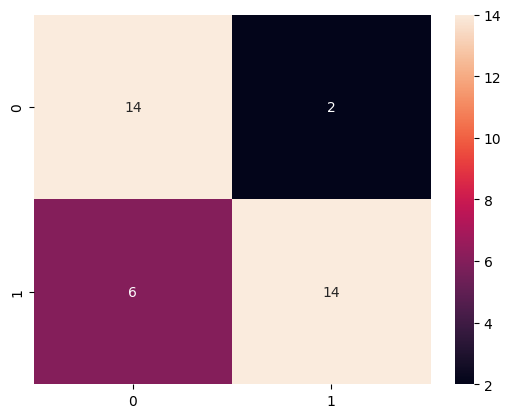

In [89]:
print(confusion_matrix(y_test, y_pred_xgb))
sns.heatmap(confusion_matrix(y_test,y_pred_xgb),annot=True)

In [90]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.70      0.88      0.78        16
           1       0.88      0.70      0.78        20

    accuracy                           0.78        36
   macro avg       0.79      0.79      0.78        36
weighted avg       0.80      0.78      0.78        36



In [91]:
#hyperparameter tuning
params_xgb = {
    'n_estimators':[50,100,150,200], 'learning_rate':[0.01,0.03,0.05,0.1], 'max_depth':[3,4,5,6], 'subsample':[0.8,0.9,1.0],
    'colsample_bytree':[0.8,0.9,1.0],'gamma':[0,0.1,0.2,0.3]}

XGB =XGBClassifier(random_state=42)
xgb_cv = RandomizedSearchCV(estimator=XGB, param_distributions= params_xgb, n_iter=20, cv=5, scoring='accuracy', verbose=2, n_jobs=-1)
xgb_cv.fit(X_train,y_train)
xgb_best_params = xgb_cv.best_params_
print("Best Parameters:", xgb_best_params)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'subsample': 0.9, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 1.0}


In [92]:
xgb_2=XGBClassifier(**xgb_best_params)
xgb_2.fit(X_train,y_train)
y_pred_xgb_2=xgb_2.predict(X_test)

In [93]:
y_pred_xgb_2

array([0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0])

In [94]:
accuracy_score(y_test,y_pred_xgb_2)

0.7777777777777778

[[14  2]
 [ 6 14]]


<Axes: >

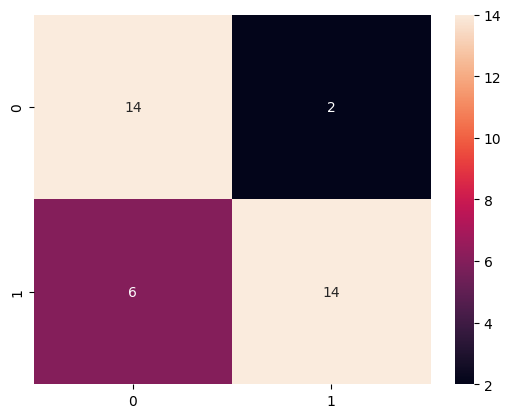

In [95]:
print(confusion_matrix(y_test, y_pred_xgb_2))
sns.heatmap(confusion_matrix(y_test,y_pred_xgb_2),annot=True)

In [96]:
print(classification_report(y_test, y_pred_xgb_2))

              precision    recall  f1-score   support

           0       0.70      0.88      0.78        16
           1       0.88      0.70      0.78        20

    accuracy                           0.78        36
   macro avg       0.79      0.79      0.78        36
weighted avg       0.80      0.78      0.78        36



In [97]:
cv_scores = cross_val_score(xgb_2, X, y, cv=5,scoring='accuracy')
print("CV Accuracy:", cv_scores.mean())

CV Accuracy: 0.7944444444444445


### Support Vector Machine

In [98]:
from sklearn.svm import SVC
svc= SVC(C=1, gamma= 0.01)
svc.fit(X_train,y_train)
y_pred_svc = svc.predict(X_test)

In [99]:
y_pred_svc

array([0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0])

In [100]:
pd.DataFrame({'Actual':y_test,'Predicted':y_pred_svc,'Error':y_test-y_pred_svc})

,Actual,Predicted,Error
19,1,0,1
42,0,0,0
153,1,0,1
78,1,1,0
145,0,0,0
15,1,1,0
24,0,0,0
68,0,0,0
113,1,1,0
118,1,1,0


#### Evaluation

In [101]:
accuracy_score(y_test,y_pred_svc)

0.8611111111111112

[[16  0]
 [ 5 15]]


<Axes: >

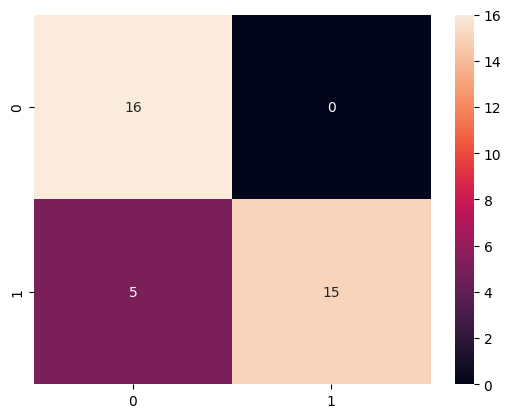

In [102]:
print(confusion_matrix(y_test, y_pred_svc))
sns.heatmap(confusion_matrix(y_test,y_pred_svc),annot=True)

In [103]:
print(classification_report(y_test, y_pred_svc))

              precision    recall  f1-score   support

           0       0.76      1.00      0.86        16
           1       1.00      0.75      0.86        20

    accuracy                           0.86        36
   macro avg       0.88      0.88      0.86        36
weighted avg       0.89      0.86      0.86        36



In [104]:
#hyperparameter tuning

param_svc = { "C": [0.1, 1, 10], "gamma": ["scale","auto", 0.01, 0.1], "kernel": ["rbf", "linear","poly"]}
SVM=SVC(random_state=42)
svm_cv= RandomizedSearchCV(estimator=SVM, param_distributions= param_svc, cv=5, scoring="accuracy",n_iter=20, n_jobs=-1, verbose=2,random_state=42)
svm_cv.fit(X_train, y_train)
svc_best_params = svm_cv.best_params_
print(f"Best parameters: {svc_best_params}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'kernel': 'rbf', 'gamma': 0.01, 'C': 10}


In [105]:
svc_2=SVC(**svc_best_params)
svc_2.fit(X_train, y_train)
y_pred_svc2=svc_2.predict(X_test)

In [106]:
y_pred_svc2

array([0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0])

In [107]:
accuracy_score(y_test,y_pred_svc2)

0.8333333333333334

[[15  1]
 [ 5 15]]


<Axes: >

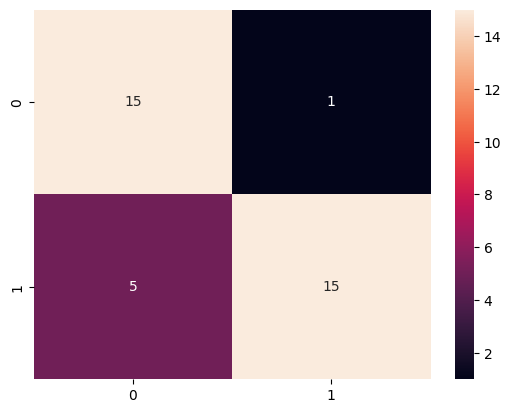

In [108]:
print(confusion_matrix(y_test, y_pred_svc2))
sns.heatmap(confusion_matrix(y_test,y_pred_svc2),annot=True)

In [109]:
print(classification_report(y_test, y_pred_svc2))

              precision    recall  f1-score   support

           0       0.75      0.94      0.83        16
           1       0.94      0.75      0.83        20

    accuracy                           0.83        36
   macro avg       0.84      0.84      0.83        36
weighted avg       0.85      0.83      0.83        36



In [110]:
cv_scores = cross_val_score(svc_2, X, y, cv=5,scoring='accuracy')
print("CV Accuracy:", cv_scores.mean())

CV Accuracy: 0.8111111111111111


### K-Nearest Neighbors (KNN)

In [111]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train,y_train)
y_pred_knn = knn.predict(X_test)

In [112]:
y_pred_knn

array([0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0])

In [113]:
pd.DataFrame({'Actual':y_test,'Predicted':y_pred_knn,'Error':y_test-y_pred_knn})

,Actual,Predicted,Error
19,1,0,1
42,0,0,0
153,1,0,1
78,1,1,0
145,0,0,0
15,1,1,0
24,0,0,0
68,0,0,0
113,1,0,1
118,1,1,0


#### Evaluations

In [114]:
accuracy_score(y_test,y_pred_knn)

0.8333333333333334

[[16  0]
 [ 6 14]]


<Axes: >

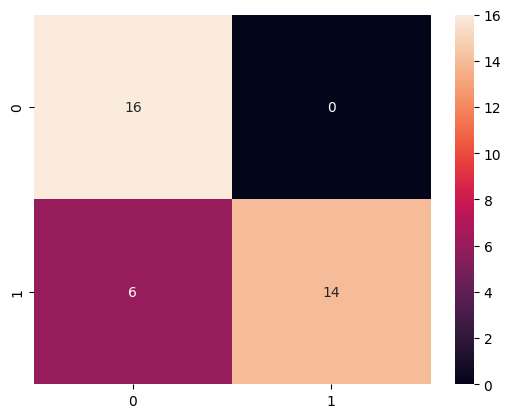

In [115]:
print(confusion_matrix(y_test, y_pred_knn))
sns.heatmap(confusion_matrix(y_test,y_pred_knn),annot=True)

In [116]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.73      1.00      0.84        16
           1       1.00      0.70      0.82        20

    accuracy                           0.83        36
   macro avg       0.86      0.85      0.83        36
weighted avg       0.88      0.83      0.83        36



In [117]:
#hyperparameter tuning
params_knn = {'n_neighbors':[3,5,7,9,11,13,15], 'weights':['uniform','distance'],
    'metric':['euclidean','manhattan','minkowski']}

KNN = KNeighborsClassifier()
knn_cv = RandomizedSearchCV(estimator=KNN, param_distributions= params_knn, n_iter=20, cv=5, scoring='accuracy', verbose=2, n_jobs=-1, random_state=42)
knn_cv.fit(X_train,y_train)
knn_best_params = knn_cv.best_params_
print("Best Parameters:", knn_best_params)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'weights': 'distance', 'n_neighbors': 13, 'metric': 'manhattan'}


In [118]:
knn_2=KNeighborsClassifier(** knn_best_params)
knn_2.fit(X_train,y_train)
y_pred_knn2=knn_2.predict(X_test)

In [119]:
y_pred_knn2

array([0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0])

In [120]:
accuracy_score(y_test,y_pred_knn2)

0.8611111111111112

[[16  0]
 [ 5 15]]


<Axes: >

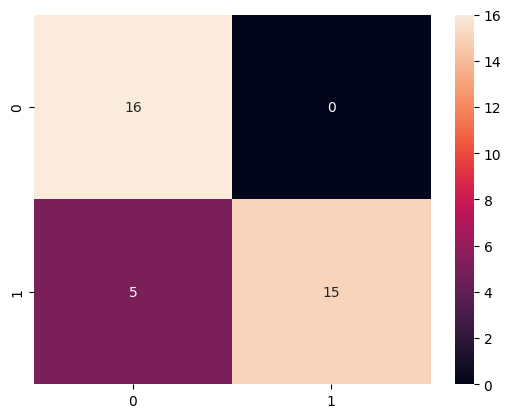

In [121]:
print(confusion_matrix(y_test, y_pred_knn2))
sns.heatmap(confusion_matrix(y_test,y_pred_knn2),annot=True)

In [122]:
print(classification_report(y_test, y_pred_knn2))

              precision    recall  f1-score   support

           0       0.76      1.00      0.86        16
           1       1.00      0.75      0.86        20

    accuracy                           0.86        36
   macro avg       0.88      0.88      0.86        36
weighted avg       0.89      0.86      0.86        36



In [123]:
cv_scores = cross_val_score(knn_2, X, y, cv=5,scoring='accuracy')
print("CV Accuracy:", cv_scores.mean())

CV Accuracy: 0.85


## Model Report

### Objectives

The primary objective of this project is to develop a machine learning model capable of predicting whether a patient is likely to have heart disease based on various medical and clinical parameters. Heart disease is one of the leading causes of mortality worldwide, and early prediction can support timely diagnosis, preventive healthcare, and effective treatment planning.

This project aims to:

* Analyze patient health records to identify patterns associated with heart disease.
* Perform exploratory data analysis (EDA) to understand feature behavior and relationships.
* Preprocess and prepare the dataset for machine learning.
* Train multiple classification models and compare their performance.
* Apply hyperparameter tuning to optimize model performance.
* Select the best-performing model for heart disease prediction.

The project follows the complete machine learning pipeline, beginning from raw data ingestion and ending with model evaluation and comparison.

### Problem Statement

The problem addressed in this project is a binary classification problem, where the target variable heart_disease_present has two possible outcomes:

* 0 → No heart disease
* 1 → Presence of heart disease

Using patient medical information such as blood pressure, cholesterol levels, chest pain type, age, exercise-induced angina, and other diagnostic parameters, the objective is to classify whether a patient is at risk of heart disease.

### Data Reading and Data Collection

The dataset was provided in two separate CSV files:

* values.csv — containing patient features
* labels.csv — containing target labels

Both datasets were merged using the common identifier patient_id.

Code Logic Used:

They were merged:

A merged file was also exported:

Why Merging Was Required ?

Since predictor variables and target labels were stored separately, merging was necessary to create one complete dataset for analysis and modeling.

Dataset Size
After merging:

* Rows: 180 observations
* Columns: 15 variables

This means the dataset contains information from 180 patients with 14 predictors and 1 target variable.

### Data Inspection

Data inspection is a critical initial stage in any data science project, as it helps in understanding the structure, quality, and characteristics of the dataset before moving toward analysis and model building. In this project, after merging the two datasets (values.csv and labels.csv) using the common key patient_id, the resulting dataset was carefully inspected to ensure the data was properly loaded, complete, and suitable for further processing. This step helps identify potential issues such as missing values, incorrect data types, duplicates, irrelevant features, and unusual patterns in the data.



##### 1) Viewing the Dataset

The first step in data inspection was viewing the dataset using df.head() and df.tail(). The head() function was used to display the first five rows of the dataset, while tail() displayed the last five rows. This provided an initial overview of the data and helped verify that the merge operation had been performed correctly.Viewing the first and last rows also gave an early sense of the types of values present in columns such as blood pressure, cholesterol, age, chest pain type, and thal values.

##### 2. Shape of the Dataset

Next, the dimensions of the dataset were checked using the df.shape function. The dataset was found to contain 180 rows and 15 columns, indicating that information for 180 patients was available along with 15 variables. Out of these, 14 were predictor variables and 1 was the target variable.

Understanding the size of the dataset is important because it gives insight into the volume of available data for analysis and model training.

##### 3. Data Types and Dataset Information

The structure and data types of all columns were examined using df.info(). This step provided detailed information about the dataset, including column names, number of non-null values, and the data type of each variable.

The dataset consisted of three major data types:

Integer (int64) features, mainly representing numerical and encoded categorical variables
Float (float64) features, representing continuous variables such as ST depression
Object features, representing categorical text variables

The numerical variables included features such as age, resting_blood_pressure, serum_cholesterol_mg_per_dl, max_heart_rate_achieved, and oldpeak_eq_st_depression, which contain continuous or measurable patient information.

Categorical variables included features such as thal, sex, chest_pain_type, and exercise_induced_angina, which represent categories or groups rather than continuous values.

The target variable heart_disease_present was identified as the dependent variable used for classification, where the model predicts whether heart disease is present or absent.

Checking data types is important because machine learning algorithms require data in appropriate formats. It also helps determine which columns may require encoding, scaling, or transformation during preprocessing.

##### 4. Statistical Summary

Descriptive statistics were generated using df.describe() to summarize the numerical variables in the dataset. This provided important statistical measures such as mean, median, standard deviation, minimum and maximum values, and quartiles (25%, 50%, and 75%). Overall, the statistical summary provided a strong understanding of data distribution and helped guide subsequent exploratory analysis and preprocessing decisions.

##### 5. Dropping Irrelevant Feature

After inspecting the dataset, the column patient_id was removed using:

This feature was dropped because it is only a unique identifier assigned to each patient and does not contain any medical or predictive information relevant to heart disease.

Including such identifier columns in machine learning models can be problematic because they do not contribute meaningful patterns and may introduce unnecessary noise into the model. Since each ID is unique, the model may attempt to treat it as a feature, which can negatively impact learning.

### Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is one of the most important stages in a data science project, as it helps uncover patterns, trends, relationships, and anomalies present in the data before model building. In this project, EDA was performed to better understand how different medical attributes relate to heart disease and to identify important predictors for classification. It also helped in detecting issues such as skewness, outliers, feature distributions, and possible relationships among variables.

The EDA process was divided into three major parts: Univariate Analysis, Bivariate Analysis, and Multivariate Analysis. Each level of analysis served a different purpose in understanding the data from simple individual feature behavior to complex interactions among multiple variables.

#### 1. Univariate Analysis

Univariate analysis involves studying one variable at a time to understand its individual behavior, distribution, and characteristics. This type of analysis is useful for detecting feature spread, skewness, outliers, frequency distributions, and general patterns within each variable.

1.1 Numerical Feature Distribution

For numerical variables, histograms along with density curves were plotted to analyze the distribution of each continuous feature. The numerical features examined included age, resting blood pressure, serum cholesterol, maximum heart rate achieved, and oldpeak (ST depression induced by exercise).

The main objective of plotting histograms was to understand the shape of distributions, whether variables followed normal distribution patterns, whether they were skewed, and whether extreme values or outliers existed.

* The age variable showed that a large number of patients were concentrated in middle-aged groups, indicating that heart disease cases in the dataset were more common among middle-aged and older individuals. This aligns with medical understanding that heart disease risk often increases with age.

 *The resting blood pressure distribution showed reasonable spread, but a few observations appeared on the higher side, suggesting possible extreme blood pressure values. This hinted at potential outliers that would later require treatment.

* The serum cholesterol variable also showed variability, with some patients having noticeably high cholesterol levels. Since high cholesterol is often linked to cardiovascular risk, this variable appeared potentially important for prediction. Some extreme values also suggested possible outliers.

* The distribution of maximum heart rate achieved appeared relatively moderate, with observations spread around central values. This feature seemed fairly well distributed without major abnormalities.

* The oldpeak variable, which measures ST depression, showed some skewness in its distribution, indicating non-symmetrical spread and possible presence of unusual values.

Overall, univariate analysis of numerical features helped identify distribution patterns, feature variability, and potential outliers. These findings later supported decisions related to outlier detection and preprocessing.

1.2 Categorical Variable Analysis

For categorical variables, countplots were used to visualize category frequencies and understand how observations were distributed across classes. The categorical variables analyzed included sex, chest pain type, number of major vessels, fasting blood sugar, resting ECG results, exercise induced angina, slope of peak exercise ST segment, and thal.

The purpose of this analysis was to examine category frequencies, detect imbalance in categories, and understand how often certain medical conditions or attributes occurred in the patient population.

* The sex feature showed the distribution of male and female patients, helping assess whether one gender was more represented in the dataset.

* The chest pain type variable showed variation across categories, with some chest pain types occurring much more frequently than others. This is important because different chest pain types may carry different levels of heart disease risk.

* The number of major vessels feature revealed how vessel blockages were distributed across patients and suggested possible relevance in disease prediction.

* The fasting blood sugar feature helped observe the proportion of patients with elevated glucose levels.

* The resting ECG categories showed variation in heart electrical activity conditions.

* The exercise induced angina feature was particularly useful because the presence or absence of angina during exercise may indicate cardiac issues.

* Similarly, the slope of peak exercise ST segment and thal showed different category distributions, and these differences may contribute significantly to classification.

From these plots, it was observed that certain chest pain categories appeared more frequently, thal categories showed noticeable variation, and some categorical features appeared likely to be strong disease indicators.

Thus, categorical univariate analysis provided valuable insights into feature frequencies, possible imbalance, and medically important category patterns.

#### Bivariate Analysis

##### Numerical Features vs Target

To analyze the relationship between numerical variables and the target variable heart_disease_present, boxplots were used to compare the distribution of each continuous feature across the two target classes: patients without heart disease (0) and patients with heart disease (1). Boxplots are particularly useful because they display median values, spread, interquartile ranges, and outliers, making it easier to compare how each feature behaves across both groups.

* Age vs Heart Disease

The boxplot for age showed that patients with heart disease generally tended to belong to slightly higher age groups compared to patients without heart disease. The median age for the disease group appeared higher, suggesting age may have a positive relationship with heart disease risk. Although there was overlap between the two classes, the shift in central tendency indicates age may contribute to prediction.

* Resting Blood Pressure vs Heart Disease

The resting blood pressure boxplot showed that patients diagnosed with heart disease tended to have slightly higher blood pressure values compared to those without disease. The disease group also showed a wider spread and some extreme observations, suggesting greater variability in blood pressure among affected patients. This supports the medical relevance of blood pressure as a cardiovascular risk factor.

* Serum Cholesterol vs Heart Disease

For serum cholesterol, the boxplot showed noticeable differences between the two groups. Patients with heart disease appeared to have relatively higher cholesterol levels, with a broader spread and presence of outliers. The larger variation and elevated values in the disease group suggest cholesterol may be an important predictor of heart disease.

* Maximum Heart Rate Achieved vs Heart Disease

The boxplot for maximum heart rate achieved showed a contrasting pattern, where patients without heart disease generally reached higher heart rates compared to those with disease. The heart disease group showed relatively lower median values, which may indicate reduced cardiac performance among affected patients. This difference suggests maximum heart rate has strong predictive relevance.

* Oldpeak (ST Depression) vs Heart Disease

Among all numerical variables, oldpeak showed one of the clearest distinctions between classes. Patients with heart disease generally exhibited higher ST depression values than patients without disease. The disease group showed higher medians and greater spread, indicating abnormal ST depression is strongly associated with heart disease presence. This suggests oldpeak may be one of the most influential predictors.

##### Categorical Features vs Target

To analyze relationships between categorical variables and heart disease, countplots were generated using the target variable as the hue. These plots helped compare how category frequencies differed between patients with and without heart disease, allowing visual identification of features associated with higher disease risk.

* Sex vs Heart Disease

The graph for sex showed variation in disease prevalence across gender categories. One gender appeared more represented among heart disease cases, suggesting sex may influence risk and contribute to prediction.

* Chest Pain Type vs Heart Disease

The chest pain type countplot showed some of the strongest class differences. Certain chest pain categories had noticeably higher counts among patients with heart disease, while others appeared more common in non-disease cases. This strong separation suggests chest pain type is an important indicator and potentially a high-impact predictive feature.

* Number of Major Vessels vs Heart Disease

The graph for number of major vessels showed a clear trend where certain vessel categories had higher association with heart disease. Patients with greater vessel involvement appeared more likely to belong to the disease class. This aligns with medical understanding and makes this feature highly significant.

* Exercise Induced Angina vs Heart Disease

The countplot for exercise induced angina showed a strong contrast between the two classes. Patients experiencing exercise-induced angina appeared more frequently in the heart disease group, indicating a strong relationship with disease presence. This was one of the clearest categorical indicators.

* Thal vs Heart Disease

The thal feature also showed strong variation between classes. Some thal categories were much more associated with heart disease than others, suggesting this variable carries substantial predictive power.

* Resting ECG and ST Segment Slope vs Heart Disease

These variables showed moderate differences across target classes. While separation was not as strong as chest pain or thal, the graphs still suggested potential association with disease outcomes.

#### Multivariate Analysis

While univariate and bivariate analyses study individual features and pairwise relationships, multivariate analysis explores interactions among multiple variables simultaneously.

In this project, a pairplot was generated using:

The purpose of the pairplot was to visualize pairwise relationships among multiple features while distinguishing classes using color based on the target variable.

This helped observe:

* Relationships among predictors
* Potential clustering patterns
* Possible separation between disease classes
* Interaction effects among variables

Some variable combinations showed visible separation between patients with and without heart disease, indicating that combinations of features may provide stronger predictive power than individual features alone.

The pairplot also helped reveal whether clusters of patients belonging to different target classes existed and whether certain variable interactions may assist classification algorithms.

These insights are valuable because machine learning models often capture multivariate relationships that may not be obvious from individual feature analysis.

### Data Preprocessing and Feature Engineering

Data preprocessing is a crucial phase in the machine learning pipeline, as it converts raw and potentially inconsistent data into a clean and model-ready format. Even well-structured datasets require preprocessing to ensure data quality, reliability, and optimal model performance. In this project, preprocessing began with assessing the dataset for missing values and duplicate records, as both issues can negatively impact analysis and model training if not addressed properly.

Before applying advanced preprocessing techniques such as outlier treatment, encoding, and scaling, it was necessary to verify whether the dataset had completeness and uniqueness issues. These checks help ensure that the models learn from accurate and unbiased data.

#### Missing Value Check

The first preprocessing step was checking for missing or null values using:

This function calculates the number of missing values in each column and helps identify whether any features have incomplete observations.

After performing this check, it was found that all columns contained zero missing values, meaning the dataset was completely populated with no null entries.

#### Duplicate Check

After confirming data completeness, the next step was checking for duplicate records using:

This function identifies rows that are exact repetitions of other rows and counts the total number of duplicates in the dataset.

The result showed:

0 duplicate records

* Interpretation of Results

This means every patient observation in the dataset was unique, and there were no repeated entries.

#### Outlier Detection and Treatment

After checking for missing values and duplicates, the next preprocessing step involved identifying and treating outliers. Outliers are extreme observations that lie significantly outside the normal range of a variable. In medical datasets, outliers may occur due to abnormal patient conditions, rare cases, measurement errors, or data entry issues. If left untreated, they can distort statistical analysis and negatively affect machine learning model performance, especially for algorithms sensitive to extreme values.

To detect outliers, the Interquartile Range (IQR) method was used. This method identifies unusual values based on the spread of the middle 50% of the data. First, the first quartile (Q1) representing the 25th percentile and the third quartile (Q3) representing the 75th percentile were calculated. The difference between them gives the Interquartile Range (IQR):

IQR=Q3−Q1

Using IQR, lower and upper bounds were computed to detect outliers:

Lower Bound:
Q1−1.5(IQR)

Upper Bound:
Q3+1.5(IQR)

Any value falling outside these limits was considered an outlier.

##### Outliers Identified

Outlier detection showed the presence of extreme values in several numerical variables:

* Resting blood pressure had 6 outliers
* Serum cholesterol had 2 outliers
* Oldpeak had 4 outliers

These variables showed unusual values that could disproportionately influence model learning if not handled properly.

##### Outlier Treatment Using Capping (Winsorization)

Instead of removing records containing outliers, capping (winsorization) was used. In this approach, values below the lower bound were replaced with the lower limit, and values above the upper bound were replaced with the upper limit.

This method was chosen instead of deleting rows because the dataset contains only 180 observations, which is relatively small for machine learning. Removing records could reduce available information and weaken model training.

Capping was preferred because:

* It retains all patient observations.
* It avoids losing potentially useful medical information.
* It reduces the influence of extreme values.
* It is safer for small datasets than deleting rows.
* It improves robustness without heavily altering distributions.

Post-treatment boxplots showed reduced spread from extreme observations, confirming that outlier influence was successfully controlled.

Overall, outlier treatment improved data quality while preserving dataset size and important patient information.

#### Encoding Categorical Variables

After cleaning numerical features, categorical variables needed transformation because machine learning algorithms generally require numerical inputs and cannot directly process text-based categories.

To convert categorical features into machine-readable format, One-Hot Encoding was applied using:

One-hot encoding converts each category into separate binary columns containing 0s and 1s.

For example, a variable such as thal with multiple categories gets transformed into multiple indicator columns representing each category.

The parameter drop_first=True was specifically used to avoid the dummy variable trap, which occurs when encoded variables become perfectly correlated with one another.

This also helps reduce multicollinearity, where highly correlated predictors can negatively impact some models such as Logistic Regression.

#### Multicollinearity Check

After encoding, the next step was checking for multicollinearity, which occurs when predictor variables are highly correlated with one another.

High multicollinearity can create problems such as:

* Unstable model coefficients
* Redundant information
* Reduced interpretability
* Poor generalization in some models

To examine this, a correlation heatmap was generated:

This visualization showed pairwise correlations among numerical predictors.

A correlation threshold of:

Correlation > 0.8

was used as an indicator of potentially problematic multicollinearity.

After analyzing correlations, no feature pairs showed severe correlation above the threshold. Some moderate relationships existed, but no predictors were highly collinear.

#### Feature Scaling

Once features were cleaned and encoded, scaling was performed.

First, predictors and target variable were separated:

Then Standardization was applied using StandardScaler.

* Why Scaling Was Necessary

Features such as:

* Age
* Blood pressure
* Cholesterol
exist on very different scales.

For example:

Cholesterol may be in hundreds
Oldpeak may be small decimals

Without scaling, large-scale variables may dominate model learning.

Scaling is especially important for:

* Logistic Regression
* Support Vector Machine (SVM)
* K-Nearest Neighbors (KNN)

These algorithms are sensitive to feature magnitude.

Overall, scaling ensured balanced contribution from all numerical features.

#### Train-Test Split

After preprocessing, the dataset was split into training and testing sets using:

An 80-20 split was used:

* Training set: 144 observations (80%)
* Testing set: 36 observations (20%)

Purpose of Train-Test Split:

The training set was used for model learning. During this phase, algorithms identify relationships between predictors and target labels.

The testing set was kept separate and used only after training to evaluate model performance on unseen data.

##### Why This Is Important

This separation helps measure:

* Generalization ability
* Predictive performance
* Risk of overfitting

Without a test set, a model may perform well on training data but poorly on new unseen data.

#### Class Distribution Check

Before model training, the target variable distribution was examined.

Class counts were:

* No heart disease (0): 100
* Heart disease present (1): 80

Interpretation

This indicates the dataset is fairly balanced, with both classes reasonably represented.

* Why Class Balance Matters ?

Checking class distribution is important because imbalanced datasets can bias models toward majority classes.

For example, if one class dominated heavily, a model might predict that class most of the time while appearing artificially accurate.

### Model Building

After completing data preprocessing, the next stage was model building, where multiple machine learning classification algorithms were trained and evaluated to identify the most effective model for predicting heart disease. Rather than relying on a single algorithm, several models were implemented to compare performance, understand how different algorithms capture patterns in the data, and select the most suitable model based on both predictive accuracy and generalization ability.

Since this is a binary classification problem, the models were evaluated primarily using accuracy, confusion matrix analysis, cross-validation, and classification metrics such as precision, recall, and F1-score.

#### Logistic Regression

The first model implemented was Logistic Regression, which served as a baseline classification model. Logistic Regression is often used as a starting point because it is simple, interpretable, and effective for binary classification tasks.

The model achieved an accuracy of 86.11%, indicating strong predictive performance.

Its confusion matrix showed:

* True Negatives (TN) = 16
* False Positives (FP) = 0
* False Negatives (FN) = 5
* True Positives (TP) = 15

This result is particularly strong because the model produced zero false positives, meaning it did not incorrectly classify healthy patients as having heart disease.

##### Performance Interpretation

The model showed strong precision, meaning positive predictions were highly reliable.

Precision:


Since false positives were zero, precision was excellent.

Recall was moderate:

because some heart disease cases were missed (false negatives = 5).

The model also produced a balanced F1-score:

Overall, Logistic Regression provided very strong baseline performance and demonstrated that the dataset contains strong separability.

#### Random Forest Classifier

The next model trained was Random Forest Classifier, an ensemble learning algorithm based on multiple decision trees.

It achieved:

* Test Accuracy: 86.11%
* Cross-validation Accuracy: 82.22%

This matched Logistic Regression in test accuracy while also showing strong cross-validation stability.

Why Random Forest Performed Well

Its performance is strong because Random Forest:

* Reduces overfitting through averaging
* Captures nonlinear relationships
* Handles feature interactions well
* Uses ensemble voting for robust prediction

Unlike a single decision tree, Random Forest combines predictions from many trees, reducing variance and improving generalization.

##### Hyperparameter Tuning Using RandomizedSearchCV

Although the base Random Forest performed well, hyperparameter tuning was performed to explore whether performance could be further improved.

RandomizedSearchCV was used for tuning.

* Why RandomizedSearchCV Was Chosen ?

RandomizedSearchCV was chosen instead of GridSearchCV because:

1. More Efficient Search:
RandomizedSearchCV samples random combinations from a parameter space, making it much faster.

2. Good for Large Parameter Spaces: 
Random Forest has multiple parameters to optimize. RandomizedSearchCV can explore broader combinations efficiently.

3. Often Finds Near-Optimal Solutions Faster: 
Instead of exhaustively testing everything, it can often find very good parameter settings with fewer iterations.

4. Suitable for This Dataset Size: 
Since the dataset is relatively small, RandomizedSearchCV provided a practical balance between optimization and efficiency.

##### Parameters Tuned:

##### 1. n_estimators:  This controls the number of trees in the forest.

More trees can improve performance and reduce variance, though too many can increase computation

##### 2. max_depth:  Controls the maximum depth of each tree.

* Lower depth prevents overfitting
* Higher depth captures complex patterns

This balances bias and variance.

##### 3. min_samples_split:  Minimum samples required to split a node.

* Helps control how aggressively trees grow.
* Higher values reduce overfitting.

##### 4. min_samples_leaf:  Minimum samples required in each leaf node.

* Prevents leaves from becoming too specific to noise.
* Improves generalization.

##### 5. max_features:  Controls number of features considered at each split.

This increases randomness among trees and can improve diversity and model robustness.

##### Tuned Random Forest Performance

After tuning:

Accuracy = 83.33%

Interestingly, performance decreased slightly from 86.11% to 83.33%.

Although tuning is often expected to improve results, it does not always do so.
In this case, the default Random Forest may already have been close to optimal for this dataset.

#### Decision Tree Classifier

A Decision Tree Classifier was trained as one of the classification models to predict heart disease presence. Decision Trees are intuitive supervised learning algorithms that make predictions by recursively splitting the data based on feature conditions. They are easy to interpret and can capture nonlinear relationships, which makes them useful for medical classification problems.

The model produced:

* Accuracy: 77.78%
* Cross-validation Accuracy: 67.78%

Compared with Logistic Regression (86.11%) and Random Forest (86.11%), the Decision Tree showed noticeably lower performance.

##### Interpretation of Base Model

Although the model achieved moderate test accuracy, its much lower cross-validation score suggested weaker generalization.

The gap between Test Accuracy and CV Accuracy indicates possible overfitting.

This means the model may have learned patterns specific to training data rather than generalized relationships.

##### Why Decision Tree Underperformed ?

Decision Trees often:

* Grow overly complex branches
* Memorize training patterns
* Become sensitive to small data changes
* Show high variance

This is especially common with small datasets, where trees may overfit easily.

##### Hyperparameter Tuning Using RandomizedSearchCV

To improve performance and control overfitting, hyperparameter tuning was performed using RandomizedSearchCV.

##### Parameters Tuned: 

##### 1. criterion :  Controls how splits are evaluated.

Values tested:

1) gini
2) entropy

* Gini minimizes impurity
* Entropy uses information gain

Testing both identifies which splitting rule works better.

##### 2. max_depth:  Controls tree complexity.

* Smaller depth reduces overfitting
* Larger depth captures more patterns

##### 3. min_samples_split:  Controls minimum samples required to split nodes.

Higher values prevent excessive branching.

##### 4. min_samples_leaf:  Prevents tiny leaf nodes that overfit noise.

##### 5. splitter:  Determines how split points are selected.

Values:

* best
* random

##### Tuned Decision Tree Performance

After tuning:

Accuracy remained 77.78%

Very little improvement occurred.

* Interpretation

This suggests the limitation was more related to algorithm behavior than parameter settings.

Even after optimization, performance stayed below stronger models.

This highlights why ensemble methods like Random Forest often outperform single trees.

#### Gradient Boosting Classifier

Gradient Boosting builds trees sequentially, where each new tree attempts to correct errors from previous trees.

Unlike Random Forest (parallel trees), boosting learns iteratively.

It can capture:

* Complex nonlinear patterns
* Feature interactions
* Difficult classification boundaries

Base model accuracy:
75%

Cross-validation:
77.78%

##### Hyperparameter Tuning (RandomizedSearchCV)

RandomizedSearchCV was used again due to efficient optimization.

##### Parameters Tuned

##### 1. n_estimators:  Number of boosting stages.
    
More estimators may improve learning.

##### 2. learning_rate:  Controls contribution of each tree.

Lower learning rates often improve generalization.

##### 3. max_depth:  Controls weak learner complexity.

Prevents boosting from becoming too complex.

##### 4. subsample:  Controls proportion of samples used per boosting stage.

Helps reduce overfitting.

##### Interpretation

Tuning improved performance slightly.

After tuning:
77.78%
    
Compared with Decision Tree:

* Better stability
* Better generalization

Compared with Random Forest/SVM:

* Lower accuracy

However:

Cross-validation ≈ test accuracy

suggests consistent generalization.

Though not top-performing, it was respectable.

#### XGBoost Classifier

An XGBoost Classifier was also implemented.
XGBoost is an advanced boosting algorithm with:

* Regularization
* Better optimization
* Reduced overfitting
* Strong predictive performance

It often outperforms standard boosting.

Results:

Base Accuracy:
77.78%

Cross-validation:
81.11%

##### Hyperparameter Tuning

RandomizedSearchCV was used.

##### Parameters Tuned

##### 1. n_estimators: Number of trees.

##### 2. learning_rate:  Controls boosting step size.

##### 3. max_depth:  Controls tree complexity.

##### 4. gamma:  Controls split aggressiveness.

Higher gamma reduces unnecessary splits.

##### 5. reg_alpha:  L1 regularization.

Helps reduce overfitting.

##### Interpretation

Unlike several models where tuning reduced performance, XGBoost improved substantially.

Tuned Accuracy:
83.33%
    
This suggests tuning helped optimize boosting structure effectively.

Compared with Gradient Boosting:

* Higher accuracy
* Better CV
* Better generalization

XGBoost emerged as a strong advanced model.

#### Support Vector Machine (SVM)

Support Vector Machine produced excellent results.

* Accuracy: 86.11%
* Cross-validation: 81.11%

This made it one of the best-performing models.

##### 5Why SVM Worked Well ?

SVM performed strongly because it:

* Finds optimal separating hyperplane
* Maximizes class margin
* Handles high-dimensional spaces well
* Works effectively with scaled data

Since scaling was applied earlier, SVM benefited significantly.

##### Hyperparameter Tuning

RandomizedSearchCV used for optimization.

##### Parameters Tuned

##### 1. C:  Controls margin flexibility.

Higher C fits training data more aggressively.

##### 2. gamma:  Controls influence of points.

Important for RBF kernel.

##### 3. kernel: Different kernels capture different decision boundaries.

##### Tuned SVM

Accuracy after tuning:
83.33%

Slight reduction.

* Interpretation

Again, tuning did not improve results.

Base SVM was already near optimal.

Important insight:

More tuning does not always mean better performance.

#### K-Nearest Neighbors (KNN)

KNN classifies based on similarity to neighboring observations.

Base KNN accuracy:
83.33%
    
Cross-validation: 85%

This made KNN one of the strongest models.

##### Why KNN Worked Well ?

KNN classifies based on similarity to neighboring observations.

It worked well likely because:

* Class boundaries were reasonably separable
* Scaling improved distance calculations
* Medical patterns may cluster naturally

##### Hyperparameter Tuning

RandomizedSearchCV used.

##### Parameters Tuned

##### 1. n_neighbors:  Most important KNN parameter.

Controls neighborhood size.

##### 2. weights:  Determines whether closer neighbors get more importance.


##### 3. metric: Distance metric choice can affect performance.

##### Why RandomizedSearchCV for KNN

Chosen because:

* Efficient search
* Faster than GridSearch
* Good for multiple parameter combinations
* Finds strong parameters with fewer iterations

##### Interpretation

Unlike many models where tuning reduced performance, KNN improved.

After tuning:

Accuracy: 86.11%

This suggests tuning successfully selected:

* Better number of neighbors
* Better weighting
* Better distance metric
* Comparative Strength

KNN achieved:

* Top-tier test accuracy
* Highest CV accuracy (85%)
* Strongest stability

This made tuned KNN arguably the best final model.

### Evaluation Metrics Used

After training the machine learning models, their performance was evaluated using multiple evaluation metrics rather than relying only on accuracy. In classification problems, especially in healthcare applications such as heart disease prediction, using multiple metrics is important because a single metric may not fully capture model performance.

For example, a model may show high accuracy but still fail to correctly identify patients with disease, which would be risky in a medical setting. Therefore, several evaluation metrics were used to measure performance from different perspectives, including Accuracy, Precision, Recall, F1-Score, and Confusion Matrix analysis.

Together, these metrics provided a comprehensive understanding of model effectiveness.

##### 1. Accuracy

Accuracy measures the proportion of total predictions that the model classified correctly.

where:

* TP (True Positive): Correctly predicted disease cases
* TN (True Negative): Correctly predicted non-disease cases
* FP (False Positive): Healthy patients incorrectly predicted as diseased
* FN (False Negative): Disease patients incorrectly predicted as healthy

Accuracy tells us how often the model makes correct predictions overall.

For example, an accuracy of 86.11% means the model correctly classified approximately 86 out of every 100 observations.

##### 2. Precision

Precision measures how reliable positive predictions are.

Precision answers the question:

Of all patients predicted as having heart disease, how many actually had heart disease?

High precision means the model makes fewer false positive errors.

##### 3. Recall (Sensitivity)

Recall, also called Sensitivity, measures how well the model identifies actual positive cases.

Recall answers:

Out of all patients who actually have heart disease, how many did the model correctly detect?

High recall means the model misses fewer disease cases.

This is extremely important in medical diagnosis because false negatives can be dangerous.

##### 4. F1 Score

The F1 Score combines precision and recall into a single metric.

F1-score provides a balance between:

* Precision
* Recall

It is especially useful when both false positives and false negatives matter.

A high F1 score means the model performs well on both:

* Correct positive predictions
* Detecting actual positives

##### 5. Confusion Matrix

In addition to metric scores, model evaluation also used a Confusion Matrix.

Unlike accuracy alone, confusion matrices show:

* Type of errors made
* False positive count
* False negative count
* Strengths and weaknesses of models

## Model Comparison Report

After training and evaluating multiple machine learning algorithms, a comparative analysis was performed to identify which models delivered the best predictive performance for heart disease classification. Model comparison is an important stage because it allows objective evaluation of different algorithms rather than relying on a single model. Since different algorithms learn patterns differently, comparing them helps determine which model best fits the dataset in terms of accuracy, stability, and generalization.

##### Comparative Interpretation of Results

The comparison revealed that model performance varied noticeably across algorithms.

* Logistic Regression achieved 86.11% accuracy, making it one of the top-performing models. This was a strong result because Logistic Regression is a relatively simple model, yet it matched more advanced algorithms. Its strong performance suggests the dataset contains meaningful class separation and that linear decision boundaries may capture a significant portion of the prediction pattern.

* Random Forest also achieved 86.11% accuracy, matching Logistic Regression. This demonstrated the strength of ensemble learning. Compared with single-tree models, Random Forest performed substantially better, likely due to its ability to reduce overfitting and capture nonlinear relationships.

* Decision Tree, with 77.78% accuracy, performed lower than most other models. This suggests a single tree was less effective at generalizing patterns in the data and was more prone to overfitting compared with ensemble approaches.

* Gradient Boosting also achieved 77.78% accuracy, showing moderate but lower performance relative to top models. Although boosting improved learning compared with a single tree, it did not outperform stronger classifiers in this project.

* Tuned XGBoost reached 83.33% accuracy, outperforming Decision Tree and Gradient Boosting while coming closer to the top-performing models. This showed the value of advanced boosting methods and hyperparameter optimization.

* Support Vector Machine (SVM) achieved 86.11% accuracy, placing it among the best models. This result suggests that the dataset benefited from margin-based classification and that SVM handled the feature space effectively after scaling.

* Tuned K-Nearest Neighbors (KNN) also achieved 86.11% accuracy, tying for highest performance among all models. Combined with its strong cross-validation results, it emerged as one of the most reliable models.

#### Best Performing Models

Based on model comparison, four models emerged as top performers:

* Logistic Regression
* Random Forest
* Support Vector Machine
* Tuned K-Nearest Neighbors

Each achieved:

86.11% accuracy

Why These Were Considered Best Models ?

These models were considered strongest because they combined:

* Highest test accuracy
* Strong predictive capability
* Good generalization performance
* Consistent classification results

Although several models tied in accuracy, additional factors such as cross-validation stability and robustness were used to compare them further.

* Logistic Regression as a Top Model

Logistic Regression stood out because it achieved top-tier performance using a relatively simple model.

Its strengths include:

* Strong baseline classifier
* Easy interpretability
* Lower complexity
* Good generalization
* Clinically interpretable coefficients

A major advantage is interpretability, which is particularly valuable in healthcare applications where understanding feature influence matters.

Its performance showed that simpler models can sometimes compete with advanced algorithms.

* Random Forest as a Top Model

Random Forest was one of the strongest models due to both high accuracy and robust ensemble behavior.

Its strengths include:

* Strong handling of nonlinear relationships
* Reduced overfitting
* Robustness through ensemble voting
* Ability to model feature interactions
* Feature importance interpretation

Compared with Logistic Regression, Random Forest may capture more complex patterns, making it a strong practical model choice.

* Support Vector Machine as a Top Model

SVM also achieved top accuracy and performed strongly because of its ability to maximize separation between classes.

Its advantages include:

* Effective classification boundaries
* Strong performance in high-dimensional data
* Good generalization
* Strong use of scaled features

Its performance confirmed that margin-based classification suited this problem well.

* Tuned KNN as a Top Model

Tuned KNN emerged as particularly impressive because it not only achieved 86.11% test accuracy, but also delivered:

Highest cross-validation accuracy: 85%

This is significant because cross-validation often provides a stronger indication of real-world generalization than test accuracy alone.

Its strengths include:

* High predictive accuracy
* Highest stability across folds
* Strong generalization
* Improvement after tuning
* Effective distance-based classification

Unlike several models where tuning reduced performance, KNN improved after optimization, making it especially noteworthy.

#### Recommended Final Model

Although multiple models tied in test accuracy, Tuned KNN can be selected as the final recommended model.

##### Why Tuned KNN Was Preferred

It was recommended because it offered:

1. High Test Accuracy

It matched the best-performing models at 86.11%.

2. Highest Cross-Validation Accuracy

Its 85% cross-validation score was the highest among all models, suggesting stronger stability.

3. Good Generalization

Performance remained strong beyond a single test split.

4. Stable Performance

Consistency across validation folds indicates reduced overfitting risk.

5. Benefited from Tuning

Unlike some models where tuning reduced accuracy, KNN improved after optimization.

For these reasons, Tuned KNN can be justified as the final selected model.

##### Alternative Final Model: Random Forest

Although KNN is recommended, Random Forest is also a strong alternative.

It may be chosen for:

1. Interpretability

Feature importance can help explain which variables drive heart disease prediction.

2. Robustness

Ensemble averaging reduces instability.

3. Strong Accuracy

It matched top performance.

4. Better Practical Use

In many real-world applications, Random Forest is often preferred for reliability and interpretability.

Thus, Random Forest is also a defensible final model.

#### Final Interpretation

The model comparison showed that several algorithms performed strongly, but Tuned KNN, supported by the highest cross-validation accuracy and strong generalization, emerged as the most suitable final model.

## Challenges Faced and Techniques Used 

During the development of this heart disease prediction project, several challenges were encountered across data preparation, feature engineering, model building, and evaluation. Addressing these challenges was an important part of the machine learning workflow because real-world datasets rarely come in a perfectly model-ready form. Different analytical and modeling techniques were applied to overcome these issues and improve the reliability and performance of the final models.

##### Challenge 1: Small Dataset Size

One of the primary challenges in this project was the relatively small dataset size, containing 180 observations. In machine learning, limited data can make it difficult for models to learn generalized patterns and increases the risk of overfitting, where models memorize training data rather than learning meaningful relationships.

##### Technique Used

To address this challenge, techniques were selected carefully to preserve as much data as possible.

Instead of deleting records during outlier treatment, winsorization (capping) was used so all observations were retained.

Cross-validation was also used to obtain more reliable estimates of model performance rather than depending only on a single train-test split.

Additionally, multiple algorithms were tested to determine which models generalized better on limited data.

##### Challenge 2: Presence of Outliers

Another challenge was the presence of outliers in features such as:

* Resting blood pressure
* Cholesterol
* Oldpeak

Extreme values can distort distributions and negatively impact model performance, particularly for algorithms sensitive to unusual observations.

##### Technique Used

The IQR method was used to detect outliers, and capping (winsorization) was applied to treat them.

This approach was preferred over removing observations because:

* It retained all patient records
* Reduced influence of extreme values
* Prevented information loss
* Was safer for a small dataset

Post-treatment boxplots confirmed reduction in extreme observations.

##### Challenge 3: Handling Categorical Variables

The dataset contained several categorical medical variables that machine learning algorithms cannot directly process.

Examples included:

* Chest pain type
* Thal
* Exercise induced angina

Without transformation, these variables could not be used in modeling.

##### Technique Used

One-hot encoding was applied to convert categorical features into numerical form.

drop_first=True was used to avoid:

* Dummy variable trap
* Multicollinearity

This ensured all features were suitable for model training while preserving information contained in categorical variables.

##### Challenge 4: Risk of Multicollinearity

Some predictor variables in medical datasets can be correlated, which may cause instability in certain models, especially linear models.

High multicollinearity can lead to:

* Unstable coefficients
* Redundant information
* Reduced interpretability

##### Technique Used

A correlation heatmap was used to assess feature relationships.

A threshold of correlation > 0.8 was checked to detect problematic correlations.

Since no severe multicollinearity was found, no variables required removal.

This step helped validate feature independence before modeling.

##### Challenge 5: Features on Different Scales

Numerical variables existed on different scales.

For example:

* Cholesterol values were large
* Oldpeak values were much smaller

This can create problems for algorithms based on distance or optimization.

##### Technique Used

Standardization using StandardScaler was applied.

This transformed features to a common scale.

This particularly benefited:

* KNN
* SVM
* Logistic Regression

Scaling prevented large-value variables from dominating learning and improved algorithm performance.

##### Challenge 6: Model Overfitting

Overfitting was a major challenge, especially with models such as Decision Tree.

Some models showed lower cross-validation performance compared to test accuracy, suggesting weaker generalization.

##### Technique Used

Several techniques were used to reduce overfitting:

* Cross-validation
* Hyperparameter tuning
* Ensemble methods
* Random Forest averaging
* Boosting methods

Using Random Forest instead of relying only on Decision Trees significantly improved stability.

Cross-validation also helped detect overfitting early.

##### Challenge 7: Selecting the Best Model

Another challenge was deciding which algorithm should be selected as the final model, especially since multiple models performed well.

Several models achieved:

86.11% accuracy

making model selection less straightforward.

##### Technique Used

Rather than selecting based only on test accuracy, model selection considered:

* Cross-validation performance
* Stability
* Generalization
* Tuning results
* Comparative evaluation metrics

This is why Tuned KNN was preferred, due to highest CV accuracy, while Random Forest remained an alternative.

Using multiple criteria made final model selection more reliable.

##### Challenge 8: Hyperparameter Optimization

Choosing suitable hyperparameters was another challenge.

Poor parameter settings can cause:

* Underfitting
* Overfitting
* Unstable performance

##### Technique Used

RandomizedSearchCV was used for hyperparameter tuning.

It was selected because:

* Faster than GridSearchCV
* Efficient for larger parameter spaces
* Explores diverse combinations
* Computationally practical

## Conclusion

This project successfully developed an end-to-end machine learning solution for heart disease prediction by applying a complete data science workflow, beginning from data understanding and preprocessing to model development, evaluation, and final model selection. The objective of the project was to build predictive models capable of identifying whether a patient is likely to have heart disease based on clinical and medical attributes, and that objective was achieved through systematic analysis and model comparison.

The project began with data inspection and exploratory data analysis, which helped understand the structure, distribution, and relationships within the dataset. Through univariate, bivariate, and multivariate analysis, important patterns were identified in variables such as age, cholesterol, blood pressure, chest pain type, exercise-induced angina, thal, and oldpeak. These analyses provided meaningful medical and statistical insights and helped identify several features likely to contribute strongly to prediction.

A major strength of the project was the emphasis placed on data preprocessing, which played a critical role in preparing high-quality inputs for model building. Missing value checks and duplicate analysis confirmed strong data quality, while outlier treatment using capping reduced the influence of extreme values without losing observations. Categorical encoding, multicollinearity checks, and feature scaling further ensured the data was transformed into a model-ready form. These preprocessing steps strengthened the reliability of subsequent modeling results.

Another significant outcome of the project was the implementation and comparison of multiple machine learning algorithms, rather than relying on a single model. Logistic Regression, Random Forest, Decision Tree, Gradient Boosting, XGBoost, Support Vector Machine, and K-Nearest Neighbors were all trained and evaluated. This comparative approach improved the robustness of the project by allowing model selection to be based on evidence rather than assumption.

The results showed that multiple models performed strongly, with Logistic Regression, Random Forest, Support Vector Machine, and Tuned KNN each achieving 86.11% accuracy, demonstrating strong predictive capability. Among these, Tuned K-Nearest Neighbors emerged as the recommended final model because it combined top-tier test accuracy with the highest cross-validation accuracy (85%), indicating strong generalization and stable performance. Random Forest also proved to be a highly robust alternative due to its interpretability and ensemble strength.

An important finding from this project was that more complex models did not always outperform simpler ones. Logistic Regression performed as well as advanced algorithms, and some tuned models even showed slightly lower performance than their untuned versions. This highlighted an important machine learning lesson: model complexity and hyperparameter tuning do not automatically guarantee superior performance. Careful evaluation and comparison remain essential.

The use of multiple evaluation metrics such as accuracy, precision, recall, F1-score, confusion matrices, and cross-validation ensured that model assessment was comprehensive. This was particularly important in a healthcare prediction problem, where correctly identifying disease cases is critical and relying only on accuracy may be insufficient.

The project also demonstrated how common data science challenges—such as limited data size, outliers, overfitting risk, and hyperparameter optimization—can be addressed using appropriate techniques including winsorization, scaling, cross-validation, ensemble learning, and randomized hyperparameter search. Overcoming these challenges contributed significantly to the reliability of the final predictive solution.


Beyond building predictive models, the project also showed the practical value of machine learning in healthcare, where predictive analytics can support early risk detection, clinical decision-making, and preventive care planning.

In conclusion, the project achieved its objective of building a reliable heart disease prediction system and demonstrated strong understanding of data analysis, machine learning modeling, evaluation, and practical problem solving. The final model provides a solid foundation for future improvements such as larger datasets, advanced ensemble methods, feature engineering, or deployment into a real-world clinical decision support system.

### Suggestions to the Hospital to Reduce Heart Disease Risk and Prevent Life-Threatening Cases

#### 1. Strengthen Early Screening Programs

One of the most important suggestions for hospitals is to strengthen early screening and cardiovascular risk assessment programs. Since the analysis showed that factors such as blood pressure, cholesterol, exercise-induced angina, and ECG-related features play an important role in predicting heart disease, hospitals should ensure routine screening for these indicators. Regular cardiac screening can help detect abnormalities at an early stage before they progress into severe disease. Special attention should be given to middle-aged and older patients as they may have higher risk. Early screening allows timely medical intervention, reduces complications, and can significantly lower the chances of fatal cardiac events.

#### 2. Use Predictive Analytics for Early Risk Identification

Hospitals should consider integrating machine learning–based predictive models into their clinical workflow to support early identification of high-risk patients. Using patient medical attributes such as age, cholesterol levels, blood pressure, chest pain symptoms, and exercise-related indicators, predictive systems can help flag patients who may be at greater risk of heart disease. This can assist doctors in identifying silent or early-stage cases that may otherwise go unnoticed. Using predictive analytics as a decision-support tool can improve diagnosis, prioritize critical patients, and support preventive treatment planning, ultimately helping prevent life-threatening situations.

#### 3. Increase Preventive Cardiac Checkup Programs

Hospitals should expand preventive cardiac health checkup programs and encourage routine cardiovascular evaluations, especially for patients with known risk factors such as hypertension, diabetes, obesity, smoking history, or family history of heart disease. Preventive checkups involving ECG testing, cholesterol screening, stress testing, and cardiac consultation can help identify risk early and reduce the probability of severe cardiac events. Instead of focusing only on treatment after symptoms worsen, hospitals should promote preventive monitoring as part of regular healthcare.

#### 4. Improve Patient Awareness and Education

Another important suggestion is increasing awareness among patients about heart disease risks and prevention. Many serious cardiac cases can be reduced if patients recognize symptoms early and seek timely treatment. Hospitals should conduct awareness programs on maintaining heart health through healthy diet, regular exercise, smoking cessation, stress management, and regular medical checkups. Educating patients about warning signs such as chest pain, breathlessness, or exercise discomfort can lead to earlier consultation and reduce emergency situations. Prevention often begins with awareness.

#### 5. Focus on High-Risk Patient Monitoring

Hospitals should establish stronger monitoring systems for patients identified as high risk. Patients with elevated blood pressure, high cholesterol, abnormal oldpeak values, exercise-induced angina, or major vessel abnormalities should receive closer follow-up and more proactive care. Instead of waiting for disease progression, hospitals can implement structured monitoring, regular follow-ups, and early interventions for these patients. Focused monitoring of vulnerable patients can help prevent complications such as heart attacks and improve long-term outcomes.

#### 6. Promote Lifestyle Intervention Programs

Hospitals should invest more in lifestyle intervention programs aimed at reducing heart disease risk factors. Since many cardiovascular conditions are influenced by lifestyle habits, preventive programs focusing on nutrition, exercise, weight management, and stress reduction can play a major role in reducing disease burden. Hospitals can offer cardiac wellness counseling, diet guidance, and supervised preventive programs for at-risk patients. Encouraging healthier lifestyles can reduce future hospitalizations and life-threatening cardiac complications.